<a href="https://colab.research.google.com/github/Violettis/Trend_e_anomalie_di_un_dataset_bibliografico/blob/main/Trend_e_anomalie_di_un_dataset_bibliografico_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto Digital Humanities 2025/26
## *Trend e anomalie di un dataset bibliografico*
- Fabbri Viola
- Gaiani Alice

## 1. Introduzione

Il progetto consiste nell'analisi esplorativa ed esplicativa di un dataset costituito da metadati descrittivi di pubblicazioni scientifiche di tipo bibliografico.

La parte esplorativa si concentra su particolari variabili del dataset originale quali: data_pubblicazione, editori, argomenti e autori, con l'aggiunta di una nuova colonna, genere_autori. L'intento è quello di individuare il range temporale intorno a cui si attestano le pubblicazioni e la prevalenza di determinati editori, argomenti ed autori: per quest'ultimi, si fanno anche alcune considerazioni in base al genere.

Sulla base di ciò, la sezione esplicativa parte con l'analisi della rilevanza che le biblioteche e la bibliografia hanno all'interno degli argomenti; procede poi guardando ai possibili legami tra gli argomenti e i generi degli autori, analizzando anche un caso particolare. Infine, l'attenzione si concentra sui due autori più prolifici per genere: Alfredo Serrai e Fiammetta Sabba. Dopo averli analizzati nel dettaglio, si confonta anche se i risultati corrispondono a quanto ottenuto nella parte esplorativa.

### 1.1 Obiettivi

Nel corso della visualizzazione ed analisi del dataset bibliografico sono sorti alcuni quesiti, a cui si è tentato di dare risposta.

Nella fase di controllo dei dati ci si è chiesto:
- Di che tipo sono le variabili? Se non corrispondono a ciò che effettivamente rappresentano, sono trasformabili? Possiamo aggiungere o separarare i dati forniti dalle variabili se rappresentano più di un'informazione?
- Vi sono dei duplicati? Possiamo escluderli dalla nostra analisi?

Nell'esplorazione dei dati si è posto come obiettivo l'analisi delle variabili scelte (data_pubblicazione, autori, argomenti ed editore), sulla base delle quali cerchiamo di capire se è possibile stabilire:
  - il periodo temporale di pubblicazione e quando si verificano picchi o cali;
  - quali sono gli autori più prolifici;
  - gli argomenti maggiormente trattati;
  - l'editore più significativo nel contesto trattato.

Una volta conclusa la parte esplorativa, ci si è dedicati a quella esplicativa, focalizzandoci su alcune domande di ricerca:
- Quanto le biblioteche, come argomento, influiscono sul database bibliografico? Qual è la loro consistenza, e cosa si guarda, di esse, nello specifico?
- È possibile che gli autori si concentrino su precisi argomenti, mentre le autrici su altri? O non ci sono distinzioni di genere in questo senso? Esistono tendenze tra gli argomenti maggiormente trattati dai due generi?
- In seguito a ciò, i due autori di maggior importanza per ciascun genere, quali sono? Essi seguono le considerazioni di livello generale sulle tendenze, rispecchiandole, o stabilendosi come eccezioni? Con chi pubblicano maggiormente, e in quali anni lo fanno?

###1.2 Dati utilizzati

| Variabile | Tipo |	Definizione | Esempio |
| :------- | :--- | :--------- | :------ |
|   id     |	str | Codice identificativo rappresentato dal link wikidata.org | 	http://www.wikidata.org/entity/Q136593329 |
|titolo |str|Titolo della pubblicazione|La mia biblioteca|
|autori | str| Autore/i della pubblicazione separati da ;| Alfredo Serrai
|genere_autori|str| Genere dell'autore o del team di autori con tre possibilità: Maschile, Femminile o Misto| Femminile
| data_pubblicazione | int| Anno della pubblicazione in numero| 1994
|argomenti|str| Argomenti della pubblicazione separati da ;|Associazione; Bibliotecario
|basi_dati|str|Banche dati da cui si sono attinte le informazioni|Scopus; DOAJ; Emerging Sources Citation Index
|doi_disponibili|str| Identificativo persistente della pubblicazione digitale per la sua ricerca sul web|10.53223/SINAPPSI_2024-01-5
|editori | str| Editore della pubblicazione| Associazione Italiana Biblioteche
|licenze_rivista|str| Licenze della rivista separate da ;|Creative Commons Attribution
|rivista|str| Rivista su cui trovare la pubblicazione|Bibliothecae.it
|edizione|int| Numero dell'edizione a cui appartiene la pubblicazione|55
|volume|int|Numero della manifestazione fisica in cui la pubblicazione compare|135
|pagine|int| Numero di pagine della pubblicazione |19
|url_disponibili|str| URL per individuare la pubblicazione su Internet|https://aibstudi.aib.it/article/view/13415

### 1.3 Organizzazione
Il progetto è stato sviluppato in un ambiente Google Colab utilizzando il linguaggio di programmazione Python. Gli strumenti principali utilizzati per la manipolazione, l'analisi e la visualizzazione dei dati sono state due librerie: Pandas e Matplotlib Pyplot.
Le operazioni hanno incluso:
- Caricamento e ispezione dei dati (alcune di queste: pd.read_csv, df.info(), df.describe())
- Bonifica e normalizzazione dei dati (alcune di queste: df.duplicated.value_counts(), df.drop(), .astype(), pd.to_numeric(errors=coerce), .explode().dropna())
- Creazione di nuove variabili calcolate (alcune di queste: genere_autori, argomenti_separati, serrai_pubblicazioni)
- Nell'analisi esplorativa si trovano aggregazioni (come: .value_counts() e visualizzazioni tramite grafici a barre orrizzontali (plot.barh()) o a torta (plot.pie())
- Nell'analisi esplicativa si è sviluppata una narrativa concentrata su di generi, argomenti e autori specifici per confrontarli ai trend generali

### 1.4 Preservazione
Il dataset utilizzato è disponibile al link https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv.

I dati in output verranno conservati nell'apposita repository Github e archiviati su Zenodo.

### 1.5 Accesso e Utilizzo

I dati di input sono rilasciati sotto licenza CC0 1.0 Universal.

Il codice è rilasciato sotto licenza CC0 1.0 Universal.

I dati di output sono rilasciati sotto licenza CC0 1.0 Universal.

# 2. Preparativi per l'analisi

##2.1 Import dei dati
Prima di poter lavorare sul database, è necessario compiere una serie di operazioni, partendo dall'import di pandas e dal caricamento del database bibliografico.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv")

## 2.2 Una visione d'insieme
A seguito dell'upload dei dati, è possibile ora andare a guardarli più nel dettaglio: per fare ciò usufruiamo di alcuni metodi fondamentali.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1792 entries, 0 to 1791
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1792 non-null   object
 1   titolo              1792 non-null   object
 2   autori              1376 non-null   object
 3   data_pubblicazione  1786 non-null   object
 4   argomenti           1043 non-null   object
 5   basi_dati           1248 non-null   object
 6   doi_disponibili     914 non-null    object
 7   editori             1589 non-null   object
 8   licenze_rivista     1476 non-null   object
 9   rivista             1583 non-null   object
 10  edizione            1377 non-null   object
 11  volume              1521 non-null   object
 12  pagine              1121 non-null   object
 13  url_disponibili     1344 non-null   object
dtypes: object(14)
memory usage: 196.1+ KB


In [4]:
df.describe()

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
count,1792,1792,1376,1786,1043,1248,914,1589,1476,1583,1377,1521,1121,1344
unique,1792,1784,849,73,735,19,912,39,7,75,43,105,973,1331
top,http://www.wikidata.org/entity/Q136593329,Editoriale,Alfredo Serrai (maschio),2020,associazione; bibliotecario,Scopus; DOAJ; Emerging Sources Citation Index,10.53223/SINAPPSI_2024-01-5,Associazione Italiana Biblioteche,Creative Commons Attribution-NonCommercial-NoD...,AIB studi,1,10,1-2,http://www.ricerchedisconfine.info/index.htm
freq,1,5,61,145,30,357,2,557,540,357,543,90,18,12


In [5]:
df.head()

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
0,http://www.wikidata.org/entity/Q136384321,Deliberazione 21 dicembre 1993: Assegnazione a...,NaN,1994,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,55,135,NaN,NaN
1,http://www.wikidata.org/entity/Q136384538,Decreto 30 aprile 1976: Regolamento interno pe...,NaN,1976,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,126,117,NaN,NaN
2,http://www.wikidata.org/entity/Q137368051,Si tocca Corfù. Viaggi in Levante,Giacomo Caputo (maschio),1931,NaN,NaN,NaN,Giornale di Sicilia Editoriale Poligrafica,NaN,Giornale di Sicilia,NaN,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q128621600,"Meldini, fantasmi a Rimini",Giorgio Calcagno (maschio),1996,bibliografia; bibliotecario,NaN,NaN,Italiana Editrice,NaN,La Stampa,222,130,19,NaN
4,http://www.wikidata.org/entity/Q111747586,Le fonti del «Libro della natura degli animali»,Davide Checchi (maschio),2017,NaN,Scopus; Arts and Humanities Citation Index; Jo...,NaN,NaN,NaN,Studi Medievali,NaN,58,525-578,NaN


Cosa è possibile notare da queste prime informazioni?


1.  Si appura la consistenza del database: 1792 righe e 14 colonne.

2. Grazie ad .info(), si scopre che la colonna "id" presenta esattamente 1792 valori, e .describe() ci assicura che ognuno di questi valori è unico: non ci si dovrebbe quindi preoccupare di eventuali doppioni, poiché ognuno ha un codice identificativo differente (l'unica eccezione sarebbe un articolo inserito più volte, ma con id diverso, come vedremo essere successo).
Invece, la colonna "titoli" presenta anch'essa 1792 valori non nulli, ma 8 di questi non sono unici: sarà meglio controllare.
Per quanto riguarda le altre colonne, tutte presentano valori nulli in maggior o minore proporzioni: di queste, solo "data_pubblicazione" è quasi interamente compilata.

3.    Un'altra informazione che si può trarre da questi metodi è che, al momento, ogni colonna ha come tipo "object": tutti i dati sono espressi in formato di stringa. Eppure, dati come "data_pubblicazione", "edizione", "volume" e "pagine" dovrebbero essere espresse in integer, forma con le quali è possibile interrogarle. Prima di trasformarle, però, è fondamentale verificare che esse siano state espresse, tra loro, in modo uniforme.

4. Guardando meglio la colonna "autori", si può notare come il sesso della persona venga incluso assieme al nome. Per una maggiore correttezza e, anche, a fini dell'analisi, sarà meglio separare queste informazioni, creando una nuova colonna.



## 2.3 Controllo dei dati



In questa fase sono apparsi fondamentali il controllo e la pulizia dei dati, con lo scopo di ottenere un database facilmente e correttamente interrogabile dal codice.

###2.3.1 Ricerca di duplicati

In [6]:
df.duplicated().value_counts()

,count
False,1792


Applicando semplicemente il metodo .duplicated al df, risulta che non esistono righe duplicate, cioè righe in cui i valori di ogni colonna sono esattamente uguali tra loro (come già sapevamo): si è però capito, ad esempio, che esistono delle righe in cui lo stesso titolo appare più volte, seppur l'id è differente. Sono solo omonimi, o esistono dei duplicati?

In [7]:
df.duplicated("titolo").value_counts()

,count
False,1784
True,8


Questra stringa di codice ci permette di scoprire che 8 titoli appaiono come duplicati nel nostro database. Serve ora vedere quali essi siano, per capire se rappresentano veramente delle ridondanze: per fare ciò, sarà necessario analizzare anche le altre informazioni disponibili per ogni riga.

In [8]:
df[df.duplicated("titolo", keep=False)].sort_values('titolo')

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
1332,http://www.wikidata.org/entity/Q102115630,A come Advocacy,Sandra Di Majo (femmina),2014,biblioteca; advocacy,NaN,NaN,Associazione Italiana Biblioteche,Creative Commons Attribution,Bibelot,2,20,NaN,https://www.aib.it/struttura/sezioni/toscana/b...
1334,http://www.wikidata.org/entity/Q102802821,A come Advocacy,Sandra Di Majo (femmina),2014,NaN,NaN,NaN,Associazione Italiana Biblioteche,Creative Commons Attribution,Bibelot,2,20,NaN,https://www.aib.it/struttura/sezioni/toscana/b...
60,http://www.wikidata.org/entity/Q137015827,Commiato,Rosa Maiello (femmina),2023,NaN,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13858,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,1,63,5-9,https://aibstudi.aib.it/article/view/13858
835,http://www.wikidata.org/entity/Q59096093,Commiato,Alfredo Serrai (maschio),2016,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/6101,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,5,1-2,https://bibliothecae.unibo.it/article/view/6101
1018,http://www.wikidata.org/entity/Q123925881,Editoriale,Fiammetta Sabba (femmina),2023,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/18704,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,12,1-2,https://bibliothecae.unibo.it/article/view/18704
1025,http://www.wikidata.org/entity/Q59281535,Editoriale,Alfredo Serrai (maschio),2012,biblioteca; bibliotecario; biblioteconomia,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/5619,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1-2,1,9-17,https://bibliothecae.unibo.it/article/view/5619
1026,http://www.wikidata.org/entity/Q60907435,Editoriale,Fiammetta Sabba (femmina); Roberta Cesana (fem...,2019,storia della bibliografia,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/8935,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,7,1-7,https://bibliothecae.unibo.it/article/view/8935
1094,http://www.wikidata.org/entity/Q59096094,Editoriale,Fiammetta Sabba (femmina); Anna Giulia Cavagna...,2016,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/6102,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,5,3-5,https://bibliothecae.unibo.it/article/view/6102
1138,http://www.wikidata.org/entity/Q109854570,Editoriale,NaN,2014,NaN,Emerging Sources Citation Index,NaN,Università di Parma,Creative Commons Attribution-NonCommercial-NoD...,NaN,NaN,NaN,NaN,NaN
689,http://www.wikidata.org/entity/Q104786709,La mia biblioteca,Giampiero Mughini (maschio),2020,bibliofilia; collezionista di libri,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/12008,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,9,470-475,https://bibliothecae.unibo.it/article/view/12008


I titoli ripetuti, quindi, sarebbero:

*   "A come Advocacy"
*   "Commiato"
*   "Editoriale"
*   "La mia biblioteca"
*  "Notizie dal CER [della Sezione ligure dell'Associazione italiana biblioteche]"

Eppure, andando a controllare gli altri dati e paragonando le altre informazioni disponibili, ci accorgiamo che solo "A come Advocacy" sembra essere l'unico vero articolo duplicato: tutte le informazioni, escluso l'id, coincidono, ed è quindi possibile concludere che tale pubblicazione deve essere stata caricata due volte sulla piattaforma Wikidata.

Dopotutto, le altre istanze appaiono come titoli generici, come "Commiato" o "La mia biblioteca", che facilmente si possono attribuire ad una risorsa, oppure indicano una tipologia specifica di pubblicazione ("Editoriale"). Per quanto riguarda "Notizie dal CER [...]" ci rimane da supporre non sia un duplicato, perché entrambe le righe sono particolarmente spoglie di informazioni aggiungitive; dalla data e dal titolo possiamo però supporre siano due pubblicazioni relative allo stesso ente, ma di anni diversi.

Procediamo quindi a droppare l'unico reale duplicato, eliminando, delle due, la riga più spoglia, cioè la 1334.




In [9]:
df1 = df.drop(1334)

In [10]:
df1[df1.duplicated("titolo", keep=False)].sort_values('titolo')

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
60,http://www.wikidata.org/entity/Q137015827,Commiato,Rosa Maiello (femmina),2023,NaN,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13858,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,1,63,5-9,https://aibstudi.aib.it/article/view/13858
835,http://www.wikidata.org/entity/Q59096093,Commiato,Alfredo Serrai (maschio),2016,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/6101,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,5,1-2,https://bibliothecae.unibo.it/article/view/6101
1018,http://www.wikidata.org/entity/Q123925881,Editoriale,Fiammetta Sabba (femmina),2023,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/18704,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,12,1-2,https://bibliothecae.unibo.it/article/view/18704
1025,http://www.wikidata.org/entity/Q59281535,Editoriale,Alfredo Serrai (maschio),2012,biblioteca; bibliotecario; biblioteconomia,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/5619,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1-2,1,9-17,https://bibliothecae.unibo.it/article/view/5619
1026,http://www.wikidata.org/entity/Q60907435,Editoriale,Fiammetta Sabba (femmina); Roberta Cesana (fem...,2019,storia della bibliografia,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/8935,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,7,1-7,https://bibliothecae.unibo.it/article/view/8935
1094,http://www.wikidata.org/entity/Q59096094,Editoriale,Fiammetta Sabba (femmina); Anna Giulia Cavagna...,2016,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/6102,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,5,3-5,https://bibliothecae.unibo.it/article/view/6102
1138,http://www.wikidata.org/entity/Q109854570,Editoriale,NaN,2014,NaN,Emerging Sources Citation Index,NaN,Università di Parma,Creative Commons Attribution-NonCommercial-NoD...,NaN,NaN,NaN,NaN,NaN
689,http://www.wikidata.org/entity/Q104786709,La mia biblioteca,Giampiero Mughini (maschio),2020,bibliofilia; collezionista di libri,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/12008,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,9,470-475,https://bibliothecae.unibo.it/article/view/12008
691,http://www.wikidata.org/entity/Q107395003,La mia biblioteca,Luciano Canfora (maschio),2021,bibliofilia; collezionista di libri,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/13080,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,10,513-517,https://bibliothecae.unibo.it/article/view/13080
1506,http://www.wikidata.org/entity/Q132167890,Notizie dal CER [della Sezione ligure dell'Ass...,NaN,2000,associazione; bibliotecario,NaN,NaN,Associazione Italiana Biblioteche,Creative Commons Attribution 3.0 Unported,Vedi anche,4,12,15-16,NaN


Riproponendo la stessa stringa di codice precedente, questa volta col nuovo database, appare che l'articolo originale di "A come Advocacy" non viene più considerato tra i possibili duplicati.

Vale anche domandarsi se altre colonne possano essere indagate sulla base di .duplicated(). Non ci appare però rilevante per due motivi:


1.   La ripetizione di alcuni valori in determinate colonne non figura come errore, ma anzi costituisce potenziali situazioni da indagare statisticamente (ad esempio, in "autori" o "argomenti");
2.   La quantità di NaN in colonne che dovrebbero rappresentare valori unici intacca significativamente la loro analisi, rendendo i dati fondamentalmente inutili da interrogare in principio.

### 2.3.2 Controllo e trasformazione dei type
Si è già precedentemente stabilito che alcune tipologie di dati numerici sono presenti nel database come stringe. Si procede, quindi, a modificare ciò con il metodo .astype(), controllando anche che questi siano stati espressi in maniera uniforme.

####2.3.2.1 Data pubblicazione
Partendo con data_pubblicazione, notiamo subito che, tentando di trasformare il tipo, sorge un errore.

(Il codice è stato preceduto da un # per evitare che la dimostrazione di ciò intacchi l'utilizzo del tasto "Esegui tutte").

In [11]:
#df1["data_pubblicazione"] = df1["data_pubblicazione"].astype("Int64")

Il codice ci dimostra subito la presenza di caratteri non numerici in alcune righe: è necessario individuare quante e quali riportino valori anomali.

In [12]:
numero_date_sbagliate = df1["data_pubblicazione"].astype(str).str.contains(r'[^0-9]', na=False).sum()
date_sbagliate = df1[df1['data_pubblicazione'].astype(str).str.contains(r'[^0-9]', na=False)]

print(f"Il numero di celle che presentano errori sono {numero_date_sbagliate}")
print(date_sbagliate[["data_pubblicazione"]])
display(date_sbagliate)

Il numero di celle che presentano errori sono 9
     data_pubblicazione
400                 NaN
419                 NaN
933                 NaN
1384                NaN
1529        1987 | 1989
1530        1992 | 1994
1531        1992 | 1994
1770                NaN
1788                NaN


,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
400,http://www.wikidata.org/entity/Q125017954,Descrizione di nuovi entozoi trovati in alcuni...,Filippo De Filippi (maschio),NaN,NaN,NaN,NaN,NaN,NaN,biblioteca Italiana,NaN,87,333-340,NaN
419,http://www.wikidata.org/entity/Q127598311,"Verrocchio e Leonardo, Leonardo e Credi",Bernard Berenson (maschio),NaN,NaN,NaN,NaN,L'Erma di Bretschneider,NaN,Bollettino d'Arte,NaN,NaN,NaN,http://www.bollettinodarte.beniculturali.it/op...
933,http://www.wikidata.org/entity/Q110067791,I diari della quarantena. Il lockdown negli ap...,Filippo Ticozzi (maschio); Lorenzo Donghi (mas...,NaN,NaN,Emerging Sources Citation Index,NaN,Università di Parma,Creative Commons Attribution-NonCommercial-NoD...,NaN,NaN,NaN,NaN,NaN
1384,http://www.wikidata.org/entity/Q104381903,Avvicendamento nell'esecutivo regionale,NaN,NaN,NaN,NaN,NaN,Associazione Italiana Biblioteche,Creative Commons Attribution,Bibelot,NaN,5,NaN,NaN
1529,http://www.wikidata.org/entity/Q128306153,Profilo ed eredità bibliografica di Giuseppe V...,Giorgio Emanuele Ferrari (maschio),1987 | 1989,bibliografia; bibliotecario; Giuseppe Valentin...,NaN,NaN,Biblioteca nazionale Marciana,NaN,Miscellanea Marciana,2/4,NaN,79; 9,NaN
1530,http://www.wikidata.org/entity/Q128588041,Il carteggio tra Ottilie von Goethe e Giuseppe...,NaN,1992 | 1994,bibliografia; bibliotecario,NaN,NaN,Biblioteca nazionale Marciana,NaN,Miscellanea Marciana,NaN,7/9,385; 457: tav.,NaN
1531,http://www.wikidata.org/entity/Q128591413,"Bontempelli a Dazzi, Bontempelli a Venezia",Alessandro Scarsella (maschio),1992 | 1994,bibliografia; bibliotecario,NaN,NaN,Biblioteca nazionale Marciana,NaN,Miscellanea Marciana,7/9,NaN,471; 459,NaN
1770,http://www.wikidata.org/entity/Q133297580,Citare Internet: un repertorio di risorse in r...,Stefania Manzi (femmina); Alessandro Corsi (m...,NaN,citazione; bibliografia,NaN,NaN,E.S. Burioni ricerche bibliografiche,NaN,ESB forum,NaN,NaN,NaN,NaN
1788,http://www.wikidata.org/entity/Q137392384,"Libri alla griglia: nascita, diffusione, fortu...",Patrizia Lucchini (femmina),NaN,antologia; insegnamento; gestione,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,NaN,NaN,NaN,NaN


Oltre alle righe NaN, è ora noto che le righe che non presentano un semplice valore numerico come data sono 3 pubblicazioni della stessa rivista, la "Miscellanea Marciana": queste devono allora contenere articoli di anni diversi. Poiché l'errore si presenta in un numero molto ridotto di casi, e non trovando un modo realmente corretto per esprimere questa loro peculiarità con un singolo numero nel nostro database, si è deciso di eliminare le tre righe contenenti valori non singoli nella colonna 'data_pubblicazione'.
Creiamo perciò, a partire dal nostro df1, un nuovo df che chiamiamo df2.

In [13]:
df2 = df1.drop([1529, 1530, 1531])

In [14]:
df2['data_pubblicazione'] = df2['data_pubblicazione'].astype('Int64') #Se tutto è stato svolto correttamente ora non ci darà più errore e il tipo di dati si convertirà da object a Int64

####2.3.2.2 Edizione
Dopodiché proviamo a convertire anche la colonna "edizione".

In [15]:
# df2["edizione"] = df2["edizione"].astype("Int64")

In [16]:
edizioni_sbagliate = df2[df2["edizione"].notna() &                               #funzione .notna() aggiunta visto l'alto numero di NaN
                         df2["edizione"].astype(str).str.contains(r'[^0-9]')]

display(edizioni_sbagliate["edizione"])

,edizione
8,6 Suppl 1
61,1-2
62,1-2
65,1-2
79,2/3
...,...
1741,3/4
1760,2 / 24
1761,2 / 24
1762,2 / 24


Esplorando la colonna "edizione", si nota come le anomalie sono molte di più e diversificate che in "data_pubblicazione"; non potendo correggerle nello stesso modo, si è deciso di forzare la conversione.

In [17]:
df2['edizione'] = pd.to_numeric(df2['edizione'], errors='coerce').astype('Int64')

A questo punto si procede a trasformare anche "volume" e "pagine", le quali presentano numerose anomalie, necessitando quindi di un'ulteriore forzatura.

In [18]:
df2['volume'] = pd.to_numeric(df2['volume'], errors='coerce').astype('Int64')
df2['pagine'] = pd.to_numeric(df2['pagine'], errors='coerce').astype('Int64')

Ora è possibile controllare, sempre usando il metodo .info(), che la trasformazione del type dei nostri dati abbia funzionato.

In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1788 entries, 0 to 1791
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1788 non-null   object
 1   titolo              1788 non-null   object
 2   autori              1373 non-null   object
 3   data_pubblicazione  1782 non-null   Int64 
 4   argomenti           1040 non-null   object
 5   basi_dati           1248 non-null   object
 6   doi_disponibili     914 non-null    object
 7   editori             1585 non-null   object
 8   licenze_rivista     1475 non-null   object
 9   rivista             1579 non-null   object
 10  edizione            1298 non-null   Int64 
 11  volume              1493 non-null   Int64 
 12  pagine              88 non-null     Int64 
 13  url_disponibili     1343 non-null   object
dtypes: Int64(4), object(10)
memory usage: 216.5+ KB


###2.3.3 Creazione di una colonna "genere"
Poiché il genere di ciascun autore è espresso di fianco al loro nome, è parso corretto individuare e trasportare tali informazioni in una nuova colonna, per poi eliminarle dalla loro collocazione originale.

Inoltre, davanti a situazioni di pluralità di autori, si è deciso di procedere nella seguente maniera:
1. Nei casi in cui due (o più) autori dello stesso sesso hanno scritto congiuntamente un articolo, il genere indicato sarà "Femminile" o "Maschile", utilizzando queste etichette per indicare tanto il genere di questi team che quello di un autore che, da solo, ha scritto una pubblicazione.
2. Nei casi in cui gli autori presentino, tra loro, generi diversi, ciò verrà indicato con genere "Misto"



In [20]:
uomini = df2["autori"].str.contains(r'\(maschio\)', na=False)
donne = df2["autori"].str.contains(r'\(femmina\)', na=False)


df2.loc[uomini & donne, "genere_autori"] = "Misto"        # uomini e donne sono serie booleane le
df2.loc[uomini & ~donne, "genere_autori"] = "Maschile"    # cui combinazioni di True e False (~)
df2.loc[~uomini & donne, "genere_autori"] = "Femminile"   # permettono di applicare le etichette di genere
                                                          # sulle righe selezionate da .loc[] nella nuova colonna

df2["autori"] = df2["autori"].str.replace(r"\(maschio\)|\(femmina\)", "", regex=True).str.strip()

In [21]:
indice_autori = df2.columns.get_loc("autori")       # ci dice la posizione indicizzata della colonna autori;
                                                    # se la printassimo corrisponderebbe a 2, cioè la terza colonna.

lista_colonne = df2.columns.tolist()                # rendiamo le nostre colonne una lista, così da
                                                    # poterci lavorare sopra e modificarne l'ordine

lista_colonne.remove("genere_autori")                    # rimuoviamo la colonna genere_autore dalla fine della lista
lista_colonne.insert(indice_autori + 1, "genere_autori") # e la reinseriamo dopo autori tramite gli indici

df2 = df2[lista_colonne]                                 #infine, rendiamo questa lista la variabile
                                                         #su cui basare l'ordine delle colonne.

df2.iloc[13:18]

,id,titolo,autori,genere_autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
13,http://www.wikidata.org/entity/Q111967342,Inizi,Anna Galluzzi ; Chiara Faggiolani,Femminile,2022,NaN,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13346,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,3,61,<NA>,https://aibstudi.aib.it/article/view/13346/182...
14,http://www.wikidata.org/entity/Q111967343,I libri di Cosimo: Italo Calvino alla Bibliote...,Andrea De Pasquale,Maschile,2022,Italo Calvino; Biblioteca Nazionale Centrale d...,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13359,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,3,61,<NA>,https://aibstudi.aib.it/article/view/13359/157...
15,http://www.wikidata.org/entity/Q114851255,La sfida della crescita esponenziale delle rac...,Fabio Venuda,Maschile,2022,information retrieval; biblioteca di ricerca,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13750,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,2,62,<NA>,NaN
16,http://www.wikidata.org/entity/Q117428586,Che cos’è una biblioteca ‘normale’?,Giuseppe Vitiello,Maschile,2022,NaN,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13415,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,1,62,<NA>,https://aibstudi.aib.it/article/view/13415
17,http://www.wikidata.org/entity/Q117428593,Gli incunaboli di Umberto Eco,Angela Nuovo ; Aldo Coletto,Misto,2022,Umberto Eco; incunabolo; fondo speciale,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13386,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,1,62,<NA>,https://aibstudi.aib.it/article/view/13386


###2.3.4 Split di autori e argomenti


Continuando ad esplorare i nostri dati, si nota come in diverse celle di alcune colonne siano state inserite più di un'informazione alla volta: è necessario quindi riuscire a separare questi valori. Si andrà a lavorare sulle colonne di "autori" e "argomenti"; anche "licenze_rivista" è stato preso in esame in un primo momento, ma poiché presenta spesso informazioni tra loro contrastanti, si è deciso di escluderlo dalle future analisi.

Dopo aver dato un primo sguardo agli eventuali separatori utilizzati tramite il metodo .tolist(), col fine di trovare un elemento comune per lo split, si comprende presto che il carattere scelto è "; ". Si procede quindi con la separazione, creando delle serie "esplose", dove questi attributi sono espressi singolarmente.


In [22]:
autori_separati = df2.autori.str.split('; ').explode().str.strip().dropna()
argomenti_separati = df2.argomenti.str.split('; ').explode().dropna().str.capitalize()

# 3. Analisi esplorativa
Dopo aver dato un primo sguardo al database e corretto alcune inesattezze, si procede ora con l'utilizzo di metodi e grafici per individuare tendenze o anomalie tra i nostri dati.

###3.1 Data pubblicazione: gli anni, tra picchi e cali
Dalla colonna "data_pubblicazione" è possibile scoprire in quale finestra temporale sono stati realizzati e pubblicati gli articoli del nostro df2. Da una prima analisi si vede che, quando il dato della colonna è stato compilato e non si considerano i valori nulli, gli anni unique sono 71, compresi tra il 1816 e il 2025.

In [23]:
df2["data_pubblicazione"].sort_values(ascending=True).unique().dropna()

<IntegerArray>
[1816, 1829, 1867, 1882, 1889, 1905, 1908, 1931, 1952, 1954, 1956, 1959, 1960,
 1961, 1963, 1965, 1968, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978,
 1980, 1981, 1982, 1983, 1984, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
 2020, 2021, 2022, 2023, 2024, 2025]
Length: 71, dtype: Int64

Inoltre, è possibile indagare i picchi e cali di pubblicazioni: data la scarsità di articoli precedenti al Novecento, si è scelto di interrogare un range temporale che si riferisca agli ultimi 100 anni.
Per la realizzazione di questo grafico si è ritenuto opportuno importare una libreria adeguata: matplotlib.pyplot.

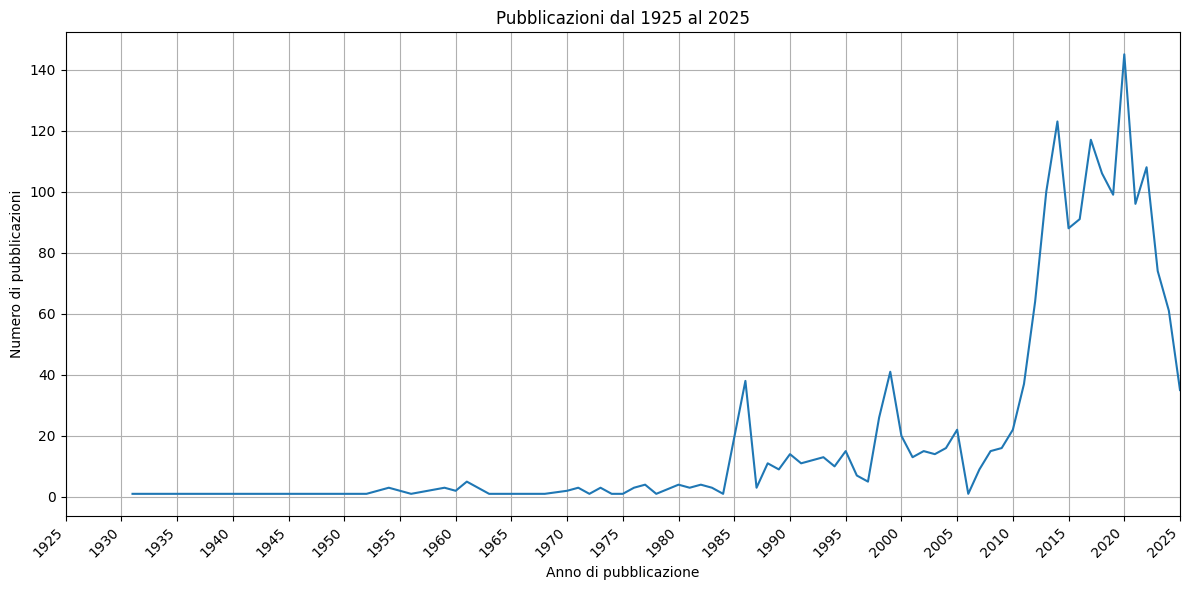

In [67]:
import matplotlib.pyplot as plt

range_temporale_100 = df2[(df2['data_pubblicazione'] >= 1925) & (df2['data_pubblicazione'] <= 2025)]
conteggio_per_anno = range_temporale_100['data_pubblicazione'].value_counts().sort_index()              #serie che indica le ripetizioni dei valori nel range temporale
                                                                                                        #ordinata cronologicamente
plt.figure(figsize=(12, 6))
conteggio_per_anno.plot.line(title='Pubblicazioni dal 1925 al 2025')
anno_di_partenza = 1925
anno_finale = 2025

plt.xlim(anno_di_partenza, anno_finale)                                               # imposta esplicitamente i limiti dell'asse x
plt.xticks(range(anno_di_partenza, anno_finale + 1, 5), rotation=45, ha='right')      # imposta i tick dell'asse x ogni 5 anni e ruota le etichette verso destra
plt.xlabel('Anno di pubblicazione')
plt.ylabel('Numero di pubblicazioni')
plt.grid(True)
plt.tight_layout()
plt.show()

Il grafico mostra un andamento tendenzialmente positivo per molti decenni, ma un netto calo che segue il 2020; nonostante ciò, è corretto affermare che negli ultimi 15 anni è avvenuto un notevole aumento nel numero degli articoli.

È possibile anche individuare i 15 anni in è stato pubblicato il maggior numero di articoli.

<Axes: title={'center': 'I 15 anni in cui si è pubblicato di più'}, xlabel='data_pubblicazione'>

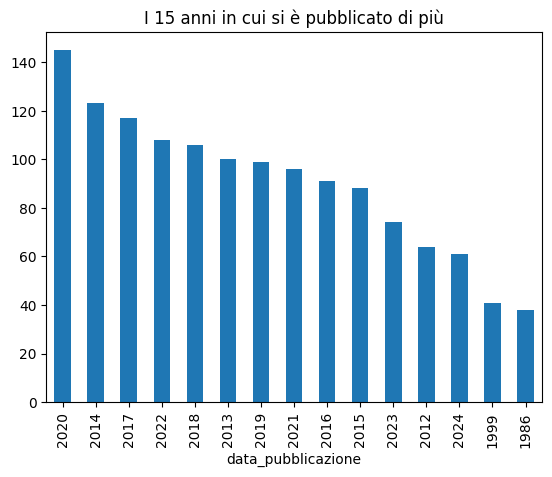

In [74]:
df2['data_pubblicazione'].value_counts().head(15).plot.bar(title='I 15 anni in cui si è pubblicato di più')

Tra gli anni con un maggior numero di pubblicazioni, notiamo come 4 su 5 di questi si riferiscano agli ultimi 10 anni.

##3.2 Editori ricorrenti
Potrebbe essere interessante anche chiedersi quali editori abbiano pubblicato il maggior numero di articoli.

In [26]:
df2.editori.value_counts().dropna()

,count
editori,
Associazione Italiana Biblioteche,556
Università di Bologna,340
Istituto Nazionale per l'Analisi delle Politiche Pubbliche,175
Università di Parma,168
Editrice Bibliografica,97
PAGEPress Publications,36
Taylor & Francis,34
Istituto Superiore di Sanità,32
Università Ca' Foscari Venezia,23


Creiamo ora un grafico per mostrare i 5 editori che più ricorrono.

<Axes: title={'center': 'I 5 editori con più pubblicazioni'}>

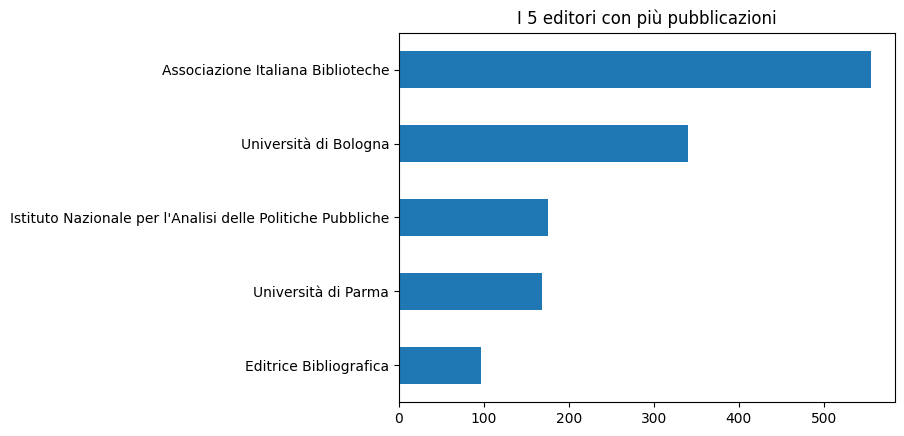

In [27]:
df2.editori.value_counts().head().sort_values().plot.barh(
    title='I 5 editori con più pubblicazioni',
    ylabel="")

Tra i maggiori editori, l'Associazione Italiana Biblioteche detiene il record, ma anche l'Università di Bologna produce molti articoli, insieme anche all'Università di Parma. Altri istituti appaiono poi nel podio.

##3.3 Argomenti

###3.3.1 I singoli argomenti
Un'altra domanda, potenzialmente molto interessante per la ricerca, è: quali sono gli argomenti che più spesso vengono collegati agli articoli pubblicati (seppur, con grande probabilità, manca un vocabolario controllato e universalmente adottato)?

Inizialmente si pone la domanda interrogando la serie "argomenti_separati".

<Axes: title={'center': 'Gli argomenti più frequenti'}>

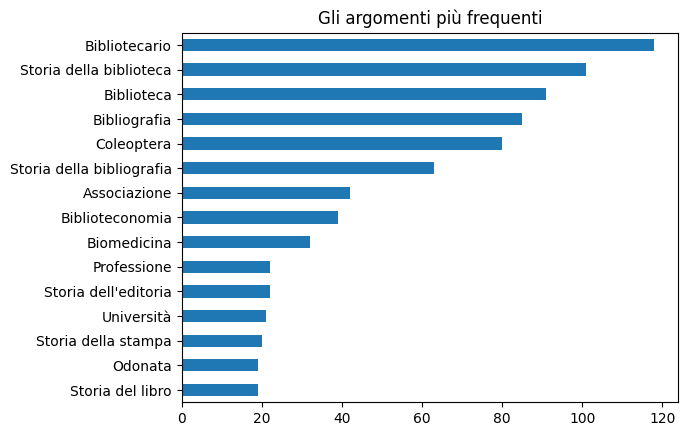

In [28]:
argomenti_separati.value_counts().head(15).sort_values().plot.barh(
    title="Gli argomenti più frequenti",
    ylabel="")

Da questo primo grafico si comprende subito che gli argomenti che ruotano intorno all'istituzione biblioteca sono i più frequenti.

Si è notata inoltre un'interessante anomalia: sono molti gli articoli che trattano di insetti nel nostro database ("Coleoptera", "Odonata", "Lepidotteri"...) ma, poiché questi non erano in alcun modo legati col resto degli articoli e degli argomenti trattati, si è deciso di non indagare oltre.

###3.3.2 E se guardassimo alle associazioni di termini?

Se si è appena indagato sugli argomenti individuali, potrebbe essere interessante anche vedere se esistono alcune particolari, ma frequenti, associazioni di argomenti oltre a quelli singoli; per fare ciò, guardiamo l'originale "argomenti" del df2.

In [29]:
def termini_in_maiuscolo(testo):                                              #definizione di una funzione che prende una stringa come input
    if pd.isna(testo):
        return testo
    termini = [termine.strip().capitalize() for termine in testo.split(';')]  #rimuoviamo gli spazi bianchi, splittiamo e capitalizziamo i termini
    return '; '.join(termini)                                                 #per poi riunirli in un'unica stringa, mantenendo il separatore ;

df2['argomenti'] = df2['argomenti'].apply(termini_in_maiuscolo)               #si applica la funzione al df2

display(df2[['argomenti']].head())

,argomenti
0,Biblioteca; Biomedicina
1,Biblioteca; Biomedicina
2,NaN
3,Bibliografia; Bibliotecario
4,NaN


<Axes: title={'center': 'Le associazioni di termini più frequenti'}>

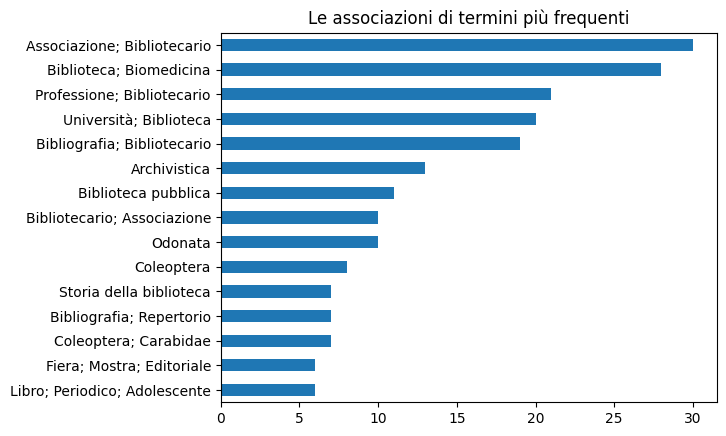

In [30]:
df2.argomenti.value_counts().head(15).sort_values().plot.barh(
    title="Le associazioni di termini più frequenti",
    ylabel=""
)

Non abbiamo rilevato associazioni di termini curiose da analizzare oltre.

##3.4 Gli autori

###3.4.1 Il genere degli autori
È possibile che gli uomini scrivano più delle donne, o viceversa? Inoltre, qual è la reale consistenza dei team misti, in cui lavorano generi diversi?

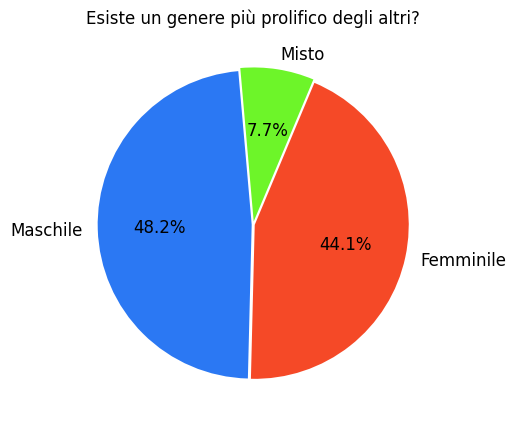

In [31]:
df2['genere_autori'].value_counts().plot.pie(
    title="Esiste un genere più prolifico degli altri?",
    autopct='%1.1f%%',
    colors=["#2B78F3", "#F54927", "#6DF529"],
    figsize=(5, 5),
    startangle=95,
    ylabel='',
    textprops={'fontsize': 12, 'color': 'black'},
    pctdistance=0.6,
    explode=(0.01, 0.01, 0.02)
);

Non notiamo una significativa distinzione di genere: gli uomini, da soli o in team dello stesso genere, sembrano pubblicare più delle donne per alcuni punti percentuali. Inoltre, i team misti non sono popolari: compongono meno dell'8% dei casi totali.

###3.4.2 Gli autori più prolifici

Quali sono gli autori che hanno contribuito di più alla pubblicazione di articoli scientifici? Utilizziamo un grafico per visualizzare questa statistica.

<Axes: title={'center': 'Gli autori che scrivono di più'}>

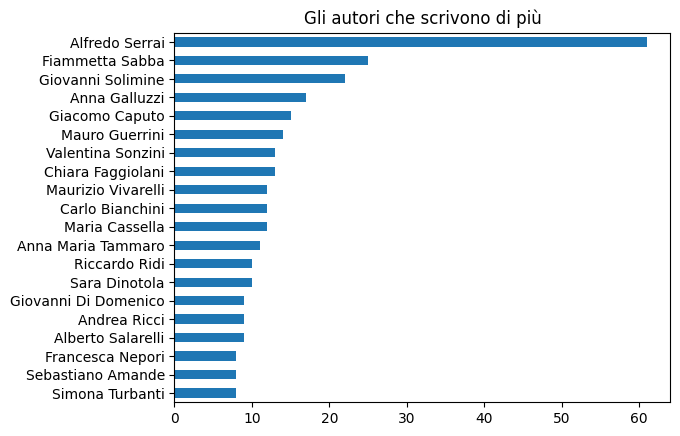

In [32]:
autori_separati.value_counts().head(20).sort_values().plot.barh(
    title="Gli autori che scrivono di più",
    ylabel="")

Tale analisi è stata compiuta sulla serie splittata degli autori. A causa dei comandi di split ed explode il numero di righe è ben superiori a quello del nostro dataframe: ciò accade perché ogni articolo realizzato da più di un autore si ripete tante volte quanti sono gli autori che lo hanno creato. Impiegando invece la sola variabile "autori", cioè alla stringa di autori che ne può comprendere uno o più al suo interno, la situazione varia leggermente: ciò ci può far comprendere, tramite il paragone, la consistenza del loro contributo all'interno di team di lavoro.

In [33]:
df2.autori.value_counts()

,count
autori,
Alfredo Serrai,61
Giovanni Solimine,18
Fiammetta Sabba,17
Maurizio Vivarelli,12
Giacomo Caputo,12
...,...
Giulia Rossi,1
Donatella Ugolini ; Cristina Casilli,1
Stefania Manzi ; Alessandro Corsi,1


In [34]:
autori_separati.value_counts()

,count
autori,
Alfredo Serrai,61
Fiammetta Sabba,25
Giovanni Solimine,22
Anna Galluzzi,17
Giacomo Caputo,15
...,...
Klaus-Peter Böttger,1
Miranda Sacchi,1
Giuseppe Dal Ferro,1


#4. Analisi esplicativa



Tramite l'analisi esplorativa si è stati in grado di comprendere alcune tendenze del database: l'enorme aumento di pubblicazioni negli ultimi 15 anni, il dominio di alcuni autori basato sul numero di pubblicazioni, l'estrema rilevanza dell'Associazione Italiana Biblioteche tra gli editori.

In questa fase si andrà più nello specifico, analizzando alcuni segmenti particolari del database, nel tentativo di comprendere più a fondo i dati posseduti.

##4.1 La rilevanza delle biblioteche

Dal grafico sugli argomenti più frequenti (paragrafo 3.3) è possibile notare come, tra i temi più ricorrenti, le biblioteche occupino le posizioni principali, che si tratti della loro storia, di chi vi lavora, o della disciplina che le regola. Nel tentativo di comprendere la loro reale consistenza all'interno del database, si è ulteriormente indagato.

<Axes: title={'center': 'Di quanti articoli le biblioteche sono (almeno un) argomento?'}>

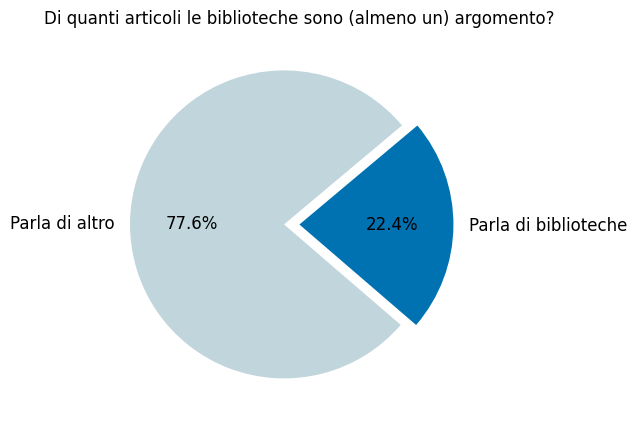

In [35]:
articoli_biblioteche = df2.argomenti.str.contains('bibliotec', case=False, na=False).value_counts()

articoli_biblioteche.index = ['Parla di biblioteche' if x == True                 #indice capace di assegnare due valori se la riga è True o False
                                                        else 'Parla di altro'
                                                     for x in articoli_biblioteche.index]

articoli_biblioteche.plot.pie(title='Di quanti articoli le biblioteche sono (almeno un) argomento?',
                              autopct='%1.1f%%',
                              colors=["#C1D5DC", "#0072B2"],
                              startangle=40,
                              figsize=(5, 5),
                              ylabel= "",
                              textprops={'fontsize': 12, 'color': 'black'},
                              explode=(0.1, 0))

Da ciò possiamo comprendere che le biblioteche sono un tema ricorrente del database, arrivando quasi ad 1/4 del totale. Eppure, dal grafico a 3.3, queste occupano le prime tre posizioni per frequenza, e ciò potrebbe indurre a pensare che la maggior parte delle pubblicazioni trattino proprio di biblioteche: questo 22,4%, nonostante sia un risultato importante, può lasciare immaginare la vastità (77,6%) e differenziazione degli argomenti trattati.

Può essere degno di nota sottolineare come, nel codice appena utilizzato, si è scelto di usare "df2.argomenti" e "non argomenti_separati": è stato scelto di agire in questo modo poiché nel secondo caso, a seguito dello split e dell'esplosione dei dati, le righe verrebbero a moltiplicarsi, alterando quindi anche le percentuali, mentre il quesito di base necessita che il numero di articoli rimanga quello originale. Se, invece, si vuole indagare anche quest'ultima possibilità, scopriremo che (come vediamo sopra) le biblioteche sono argomento del 22,4% degli articoli, ma rappresentano il 19,4% degli argomenti totali.


Ora che è chiara la consistenza degli articoli che trattano di biblioteche, è possibile andare ad indagare ulteriormente: è già noto come siano molteplici i temi e le sfaccettature possibilmente racchiuse sotto questo termine. Si procede così analizzando più nel dettagli gli argomenti che ruotano intorno alle biblioteche.

<Axes: title={'center': 'Quali sono le diverse accezioni?'}>

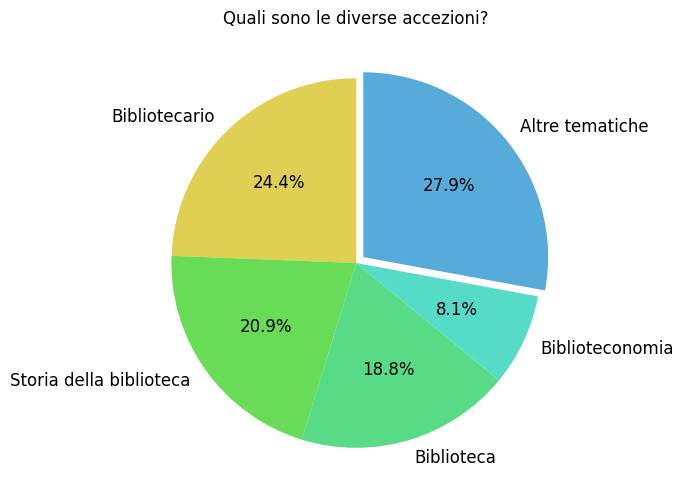

In [36]:
argomenti_biblioteche = argomenti_separati[argomenti_separati.str.contains('bibliotec', case=False, na=False)]

conteggio_argomenti = argomenti_biblioteche.value_counts()       #serie che abbina gli argomenti alla loro frequenza
top_4_argomenti = conteggio_argomenti.head(4)
altri_argomenti = conteggio_argomenti.iloc[4:].sum()             #somma tutti gli argomenti dopo il 4*

#noi sappiamo che gli argomenti sono più di 4, e quindi altri_argomenti esiste, ma
#nel caso fosse un'info conosciuta dal principio, creiamo un if-else che comprenda la possibilità
#di usare anche i soli primi 4 nel grafico

if altri_argomenti > 0:          #condizione: se altri_argomenti esiste
    accezioni_biblioteche = pd.concat([top_4_argomenti, pd.Series({'Altre tematiche': altri_argomenti})]) #pd.Series è una serie temporanea
else:
    accezioni_biblioteche = top_4_argomenti

accezioni_biblioteche.plot.pie(title="Quali sono le diverse accezioni?",
                                   autopct='%1.1f%%',
                                   colors=["#DFCF53", "#68DB57", "#57DB87", "#57DBC9", "#57ABDB"],
                                   startangle=90,
                                   figsize=(6, 6),
                                   ylabel= "",
                                   textprops={'fontsize': 12, 'color': 'black'},
                                   explode=(0, 0, 0, 0, 0.05))

Per avere un'idee di quali queste "altre tematiche" siano, è possibile mostrare le accezioni subito successive:

In [37]:
print("Seguono, tra gli argomenti più trattati intorno alle biblioteche,")
print(conteggio_argomenti.iloc[4:].head(10))

Seguono, tra gli argomenti più trattati intorno alle biblioteche,
argomenti
Biblioteca pubblica                              18
Biblioteca digitale                               9
Servizio bibliotecario nazionale                  7
Biblioteca personale                              7
Professione bibliotecaria                         6
Scienza dell'informazione e delle biblioteche     5
Biblioteca monastica                              5
Biblioteche antiche                               5
Biblioteca di alessandria                         4
Biblioteca accademica                             4
Name: count, dtype: int64


###4.1.1 La bibliografia
In modo simile alla biblioteca, anche l'argomento della bibliografia appare tra i temi di maggior frequenza nel grafico a 3.3, occupando la 4* e 6* posizione. Si è però appena constatato, con le biblioteche, che anche gli argomenti che appaiono più comuni sono in realtà una parte fondamentalmente ridotta del database. Brevemente, verifichiamo la consistenza per la disciplina bibliografica.

<Axes: title={'center': 'Percentuale di articoli totali contenenti "bibliografia"'}>

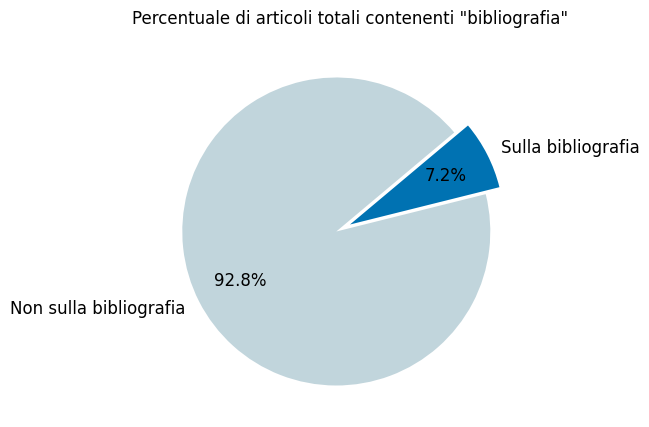

In [38]:
argomenti_total_bibliografia = df2.argomenti.str.contains('bibliografia', case=False, na=False).value_counts()
argomenti_total_bibliografia.index = ['Sulla bibliografia'  if x == True
                                                             else 'Non sulla bibliografia'
                                                            for x in argomenti_total_bibliografia.index
]

argomenti_total_bibliografia.plot.pie(
    title='Percentuale di articoli totali contenenti "bibliografia"',
    autopct='%1.1f%%',
    colors=["#C1D5DC", "#0072B2"],
    startangle=40,
    figsize=(5, 5),
    ylabel= "",
    textprops={'fontsize': 12, 'color': 'black'},
    explode=(0.1, 0),
    pctdistance=0.7)

Si comprende quindi che anche la bibliografia è un tema frequente ma, allo stesso tempo, limitato.

##4.2 Esistono correlazioni tra genere e argomento?

È possibile che uomini e donne, più o meno inconsciamente, siano portati ad occuparsi di un argomento o disciplina specifica, rispetto ad altre dello stesso settore? Sarebbe corretto affermare che un genere, tanto individualmente che in team dello stesso sesso, scrive più dell'altro rispetto ad un dato tema o, invece, non ci sono tendenze speciali in questo senso?

###4.2.1 Gli argomenti più frequenti per genere
Tramite i grafici, si possono individuare le tendenze tra gli argomenti per ciascun genere: maschile, femminile e misto.

Si è scelto di mantenere fissi i colori per ciascun argomento nei tre schemi, così da poter notare subito la loro eventuale ricorrenza.

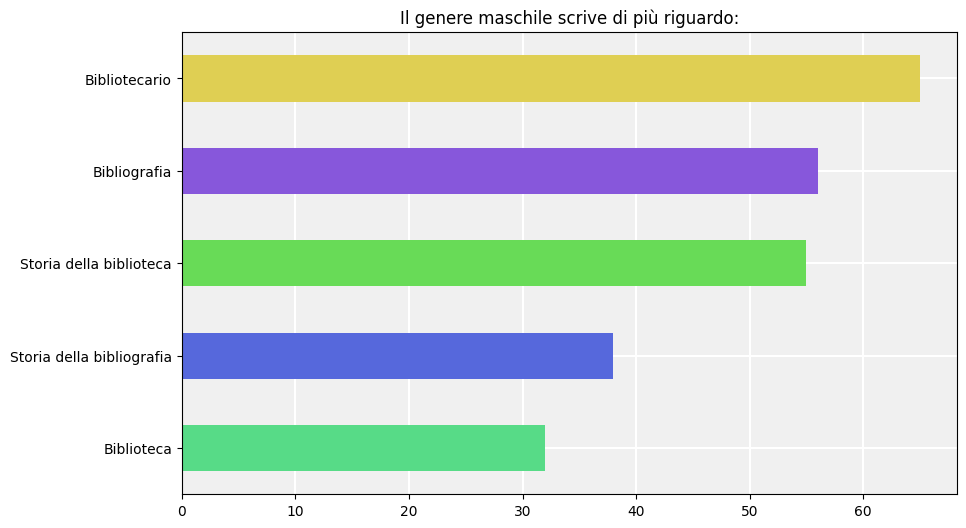

In [39]:
df_maschile = df2[df2['genere_autori'] == 'Maschile']
argomenti_maschile_separati = df_maschile['argomenti'].str.split('; ').explode().dropna().str.capitalize()

ax = argomenti_maschile_separati.value_counts().head(5).sort_values().plot.barh(
    title='Il genere maschile scrive di più riguardo:',
    color=["#57DB87", "#5668DC", "#68DB57", "#8757DB", "#DFCF53"],
    figsize=(10, 6),
    grid=True,
    ylabel="",
    width=0.5);

ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linewidth=1.5)
ax.set_axisbelow(True)


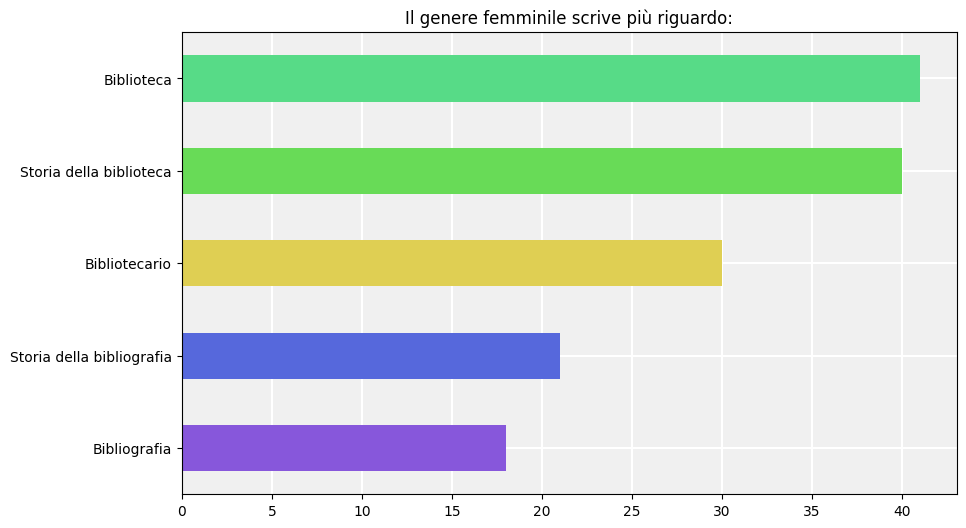

In [40]:
df_femminile = df2[df2['genere_autori'] == 'Femminile']
argomenti_femminile_separati = df_femminile['argomenti'].str.split('; ').explode().dropna().str.capitalize()

ax = argomenti_femminile_separati.value_counts().head(5).sort_values().plot.barh(
    title='Il genere femminile scrive più riguardo:',
    color=["#8757DB", "#5668DC", "#DFCF53", "#68DB57", "#57DB87"],
    figsize=(10, 6),
    grid=True,
    ylabel="",
    width=0.5);

ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linewidth=1.5)
ax.set_axisbelow(True)

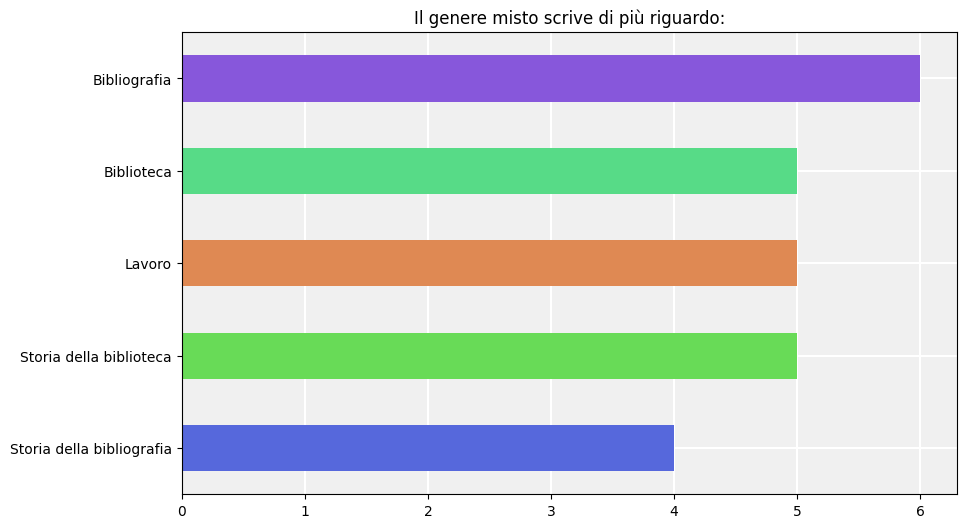

In [41]:
df_misto = df2[df2['genere_autori'] == 'Misto']
argomenti_misto_separati = df_misto['argomenti'].str.split('; ').explode().dropna().str.capitalize()

ax = argomenti_misto_separati.value_counts().head(5).sort_values().plot.barh(
    title='Il genere misto scrive di più riguardo:',
    color=["#5668DC", "#68DB57", "#DF8953", "#57DB87", "#8757DB"],
    figsize=(10, 6),
    grid=True,
    ylabel="",
    width=0.5);

ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linewidth=1.5)
ax.set_axisbelow(True)

Da ciò è possibile notare come, tendenzialmente, le tematiche più affrontate sono le stesse che si sono già individuate in precedenza (paragrafo 3.3, ma anche 4.1): gli argomenti più frequenti sono anche quelli di cui ciascun genere scrive maggiormente. In ogni caso è però presente una piccola differenza: gli uomini tendono a scrivere di più riguardo alla disciplina della bibliografia e della sua storia rispetto alla loro controparte femminile, mentre le donne si concentrano maggiormente sulla biblioteca, la sua storia e professione, con minor spazio per la bibliografia.

Per quanto riguarda i team di uomini e donne, i dati non sono numerosi e non permettono di compiere riflessioni particolarmente ampie: si ritrovano però gli stessi temi dei generi maschili e femminili, con un'eccezione, cioè dell'argomento "lavoro". È lecito, però, domandarsi cosa questo indichi precisamente: si riferisce alla professione bibliotecaria, o ha altri significati?

####4.2.1.1 L'argomento "lavoro"

Qual è il significato di questa particolare etichetta trovata tra i generi misti, in quali casi il termine viene usato? Inoltre, è qualcosa di cui scrivono maggiormente i team eterogenei? Si procede ad indagare.

Si utilizza display per dare un primo sguardo ai casi in cui questa parola viene usata, comprendendo fin da subito la varietà degli argomenti e contesti.

In [42]:
lavoro_argomenti = df2[df2['argomenti'].str.contains('lavoro', case=False, na=False)]
display(lavoro_argomenti["argomenti"])

,argomenti
1561,Lavoro; Crisi economica
1565,Lavoro; Recessione; Giovane adulto
1569,Lavoro; Piccola e media impresa
1571,Politica; Disoccupazione; Lavoro
1574,Mercato del lavoro; Innovazione tecnologica; G...
1575,Mercato del lavoro; Industria 4.0; Tecnologie ...
1576,Lavoro; Organizzazione
1584,Donna; Lavoro; Imprenditorialità
1590,Data mining; Ricerca del lavoro
1592,Pubblica amministrazione; Lavoro; Sicurezza


Nel tentativo di individuare i casi in cui lavoro non compare da solo, e non è quindi capace di dare una spiegazione più ampia su di sé, si ricerca gli argomenti in cui esso è più frequentemente contenuto o associato (cioè in cui "lavoro" è almeno uno degli argomenti).

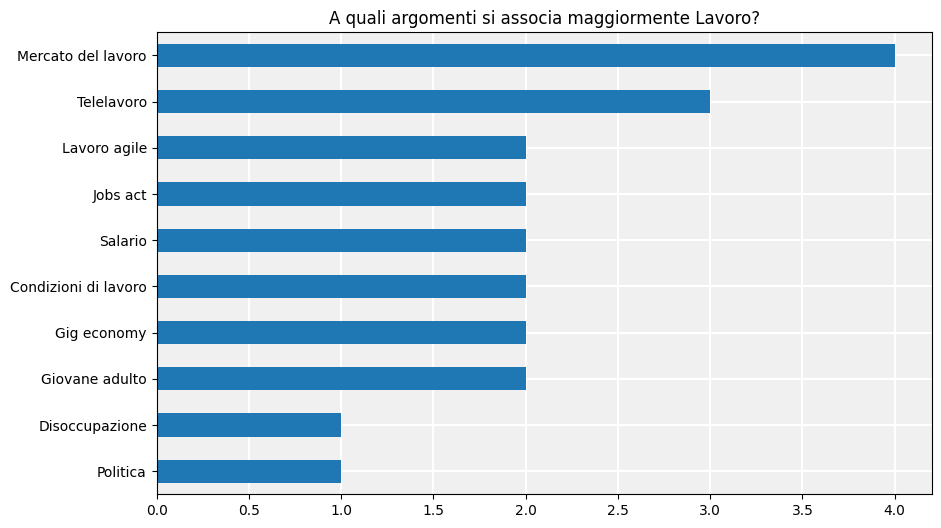

In [43]:
lavoro_frequenza = lavoro_argomenti['argomenti'].str.split('; ').explode().dropna()
lavoro_frequenza = lavoro_frequenza[lavoro_frequenza.str.lower() !="lavoro"]

ax = lavoro_frequenza.value_counts().head(10).sort_values().plot.barh(
    title= "A quali argomenti si associa maggiormente Lavoro?",
    figsize=(10, 6),
    grid=True,
    ylabel="",
    width=0.5);

ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linewidth=1.5)
ax.set_axisbelow(True)

Si comprende quindi che non si tratta del lavoro bibliotecario, ma rappresenta piuttosto l'occupazione di ciascun individuo. Infine, è possibile chiedersi che genere maggiormente scriva di lavoro:

<Axes: title={'center': 'Quali generi scrivono di lavoro?'}>

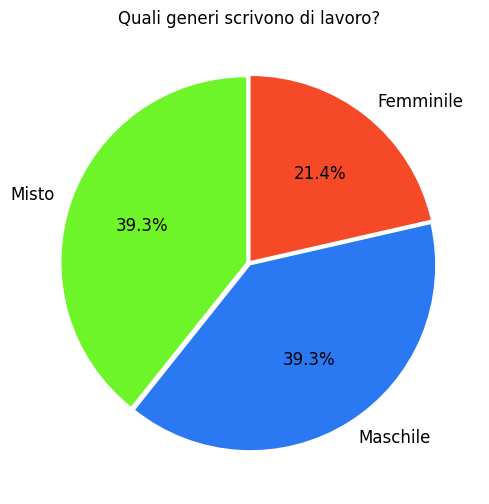

In [44]:
genere_lavoro = lavoro_argomenti['genere_autori'].value_counts()
genere_lavoro.plot.pie(title="Quali generi scrivono di lavoro?",
                                   autopct='%1.1f%%',
                                   colors=["#6DF529", "#2B78F3", "#F54927"],
                                   startangle=90,
                                   figsize=(6, 6),
                                   ylabel= "",
                                   textprops={'fontsize': 12, 'color': 'black'},
                                   explode=(0.015, 0.015, 0.015))

###4.2.2 Genere: singoli o team?

Un'ultima interessante riflessione potrebbe basarsi sulla separazione tra autori singoli e in gruppo. Finora ci si è concentrati sul genere, portando a raggruppare individui e team secondo tale criterio: come risultato, si è determinato che nessun genere prevarica sull'altro e che la scrittura in team eterogenei non è molto frequente.

Appare però anche interessante domandarsi: esisterebbero delle differenze se si separasse l'autrice donna sola dai gruppi di donne, e gli autori uomini dai gruppi omogenei dello stesso sesso? Le percentuali che si verrebbero a creare sarebbero in linea con il già noto team eterogeneo di "misti"? C'è un genere che, rispetto all'altro, ha una maggior propensione a formare gruppi di lavoro con studiosi dello stesso genere?

Per fare ciò, è necessario andare a separare i team omogenei, delineando quando un articolo, ad esempio, è stato scritto da una sola donna o da più donne.

In [45]:
df3 = df2.copy()

def rendendo_plurale(row):                    #definiamo una funzione che agisce
    genere = row['genere_autori']             #su genere_autori e convertiamo le
    autori_str = str(row['autori'])           #righe di AUTORI (non genere)
                                              #in str così da evitare i NaN

    if pd.isna(row['autori']):
        return genere

    if ';' in autori_str:                     #se viene trovato un ; tra gli autori
        if genere == "Femminile":             #allora rendiamo i generi delle persone
            return "Donne"                    #plurali
        elif genere == "Maschile":
            return 'Uomini'
        elif genere == "Misto":
            return "Team misto"
    else:                                     #se non trova un ; vuol dire che
        if genere == "Femminile":             #sono autori singoli
            return "Donna"
        elif genere == "Maschile":
            return "Uomo"

    return genere

df3["genere_autori"] = df3.apply(rendendo_plurale, axis=1)      #applichiamo la funzione al df3

<Axes: title={'center': 'Le nuove proporzioni di genere rispetto alle pubblicazioni'}>

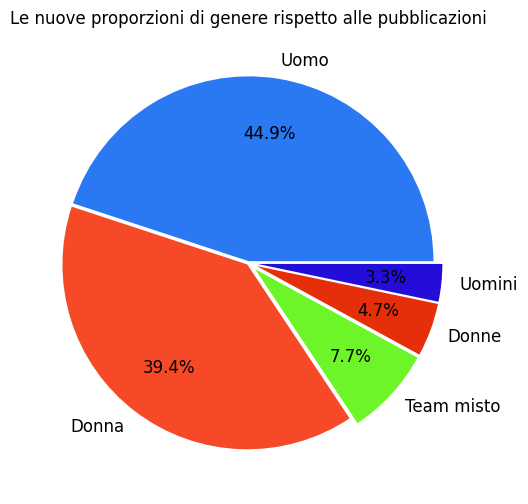

In [46]:
df3["genere_autori"].value_counts().plot.pie(
    title= "Le nuove proporzioni di genere rispetto alle pubblicazioni",
    autopct='%1.1f%%',
    colors=["#2B78F3", "#F54927", "#6DF529", "#E52F0A", "#240DD9"],
    figsize=(6, 6),
    ylabel= "",
    textprops={'fontsize': 12, 'color': 'black'},
    explode=(0.01, 0.01, 0.05, 0.05, 0.05),
    pctdistance=0.7)

Rispetto all'analisi al paragrafo 3.4.1, notiamo dei risultati simili: gli uomini, come autori singoli, pubblicano più che le autrici donna, ma possiamo vedere che quest'ultime hanno una (leggera) maggior propensione a formare team dello stesso sesso. Inoltre, sommando le percentuali di Uomini e Donne, otteniamo come risultato 8%, ben simile alla consistenza di articoli scritti da team misti: non appare quindi più comune scrivere in team dello stesso genere rispetto a misti, o viceversa.

Infine, si comprende che, rispetto al totale di pubblicazioni, il 15.7% degli articoli è stato scritto da più mani.

##4.3 Le stelle del database

Sulla base della nostra precedente analisi (paragrafo 3.4.2), possiamo ora delineare i profili dei due autori più prolifici in base al genere: Alfredo Serrai per il genere maschile e Fiammetta Sabba per il genere femminile.
Si conduce un'analisi che possa verificare se le considerazioni sviluppate finora possono essere applicate anche questi due autori di punta.

###4.3.1 Alfredo Serrai

Di Serrai è già noto che egli sia l'autore più profilico e, poichè il numero di pubblicazioni non aumenta in seguito alle operazioni di split, scrive esclusivamente da solo. È possibile però domandarsi:

- In che periodo scrive i suoi 61 articoli?
- Qual è l'anno in cui è più prolifico?
- Quali sono i 5 argomenti di cui tratta di più nei suoi articoli? Corrispondono al grafico sul genere?
- Con che editori pubblica di più?

####4.3.1.1 Anni in cui pubblica
Sulla base degli articoli che hanno come autore Alfredo Serrai, si procede ad individuare gli anni di pubblicazione.

In [47]:
serrai_pubblicazioni = df2[df2['autori'].str.contains('Alfredo Serrai', na=False)]
print(serrai_pubblicazioni['data_pubblicazione'].unique().dropna())

<IntegerArray>
[2022, 2020, 2021, 2013, 2014, 2024, 2015, 2019, 2016, 2018, 2012, 2017, 2023]
Length: 13, dtype: Int64


A partire dalle pubblicazioni che lo vedono come autore, si crea un grafico che mostri quanti articoli ha pubblicato per ogni anno.

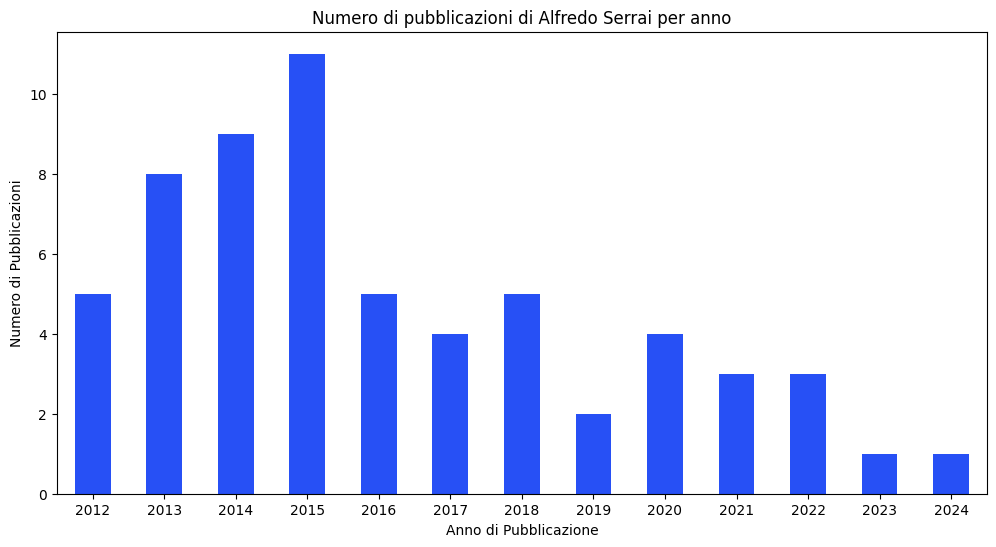

In [48]:
serrai_pubblicazioni = df2[df2['autori'].str.contains('Alfredo Serrai', na=False)]
pubblicazioni_per_anno_serrai = serrai_pubblicazioni['data_pubblicazione'].value_counts().sort_index()

pubblicazioni_per_anno_serrai.plot.bar(
    title="Numero di pubblicazioni di Alfredo Serrai per anno",
    figsize=(12, 6),
    ylabel='Numero di Pubblicazioni',
    xlabel='Anno di Pubblicazione',
    color='#2750F5',
    rot=360
);

Da ciò si viene a conoscenza che Serrai, nell'anno per lui più prolifico, ha scritto 11 articoli.

####4.3.1.2 Argomenti maggiormente trattati
Sempre tenendo conto delle pubblicazioni attribuite ad Alfredo Serrai, si inviduano ora i 5 argomenti singoli (cioè splittati) che si ripetono di più nelle sue pubblicazioni.

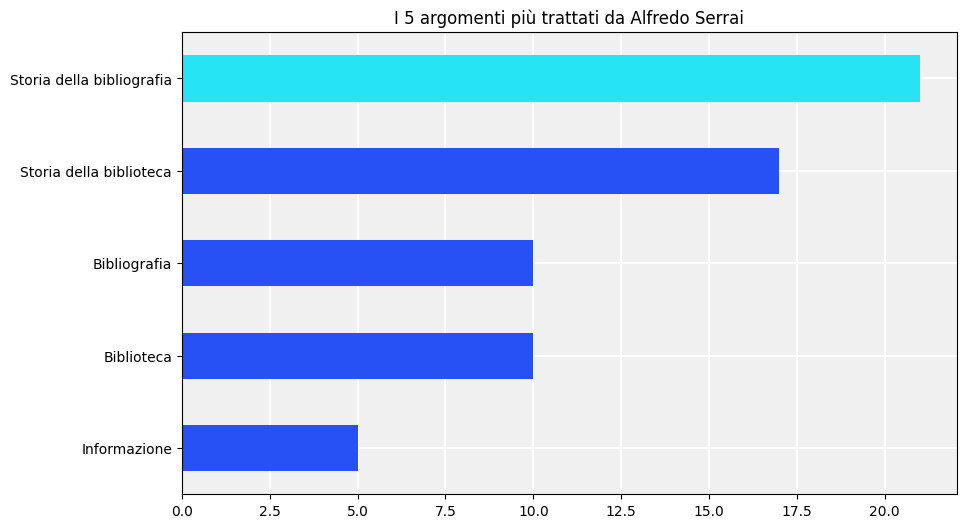

In [81]:
argomenti_serrai_separati = serrai_pubblicazioni['argomenti'].astype(str).str.split('; ').explode().dropna()
argomenti_serrai_separati = argomenti_serrai_separati[argomenti_serrai_separati.str.lower() != 'nan']

ax = argomenti_serrai_separati.value_counts().head(5).sort_values().plot.barh(
    title='I 5 argomenti più trattati da Alfredo Serrai',
    color=['#2750F5','#2750F5','#2750F5','#2750F5','#27E4F5'],
    figsize=(10, 6),
    grid=True,
    ylabel="",
    width=0.5);
ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linewidth=1.5)
ax.set_axisbelow(True)

I 5 argomenti maggiormente trattati da Alfredo Serrai, genere maschile, sono: Storia delle bibliografia, Storia della biblioteca, Bibliografia, Biblioteca e informazione.
Se si fa riferimento alla  precedente analisi sugli argomenti maggiormente trattati in base al genere degli autori (paragrafo 4.2.2), si noterà che quattro argomenti coincidono. Serrai si differenzia per l'argomento 'Informazione'.

####4.3.1.3 Editori con cui pubblica
Si indaga quali editori abbiano pubblicato gli articoli di Alfredo Serrai. Nella considerazione, non sapendo effettivamente quanti editori pubblichino Serrai, si parte considerando solo i 5 più ripetuti.

In [50]:
editori_serrai = serrai_pubblicazioni['editori'].astype(str).dropna()
top_5_editori_serrai = editori_serrai.value_counts().head(5)

print('Top 5 editori per Alfredo Serrai')
display(top_5_editori_serrai)

Top 5 editori per Alfredo Serrai


,count
editori,
Università di Bologna,60
Associazione Italiana Biblioteche,1


Si scopre che, quando il dato è stato compilato, sono solo due gli editori che pubblicano Serrai nel nostro dataset.

###4.3.2 Fiammetta Sabba
Dall'analisi esplorativa si è a conoscenza che Fiammetta Sabba non scrive solo da sola, ma anche in team.
Risulta essere tra gli autori di 25 articoli, di cui 17 come unica autrice.
Si comincia analizzando prima le pubblicazioni in cui risulta non essere l'unica autrice.

- Sono team tutti al femminile o misti?
Pubblica sempre con le stesse persone o variano quando è coautrice?

- In che periodo scrive?
Anno più prolifico?
L'anno più prolifico corrisponde all'anno in cui ha pubblicato anche in team?

- Quali sono gli argomenti di cui tratta di più nei suoi articoli? Corrispondono al grafico sul genere?

- Con che editori pubblica di più?

####4.3.2.1 Le pubblicazioni in team
Si tenta ora di comprendere meglio i gruppi di lavoro in cui Sabba ha partecipato e e se l'autrice ha lavorato più volte con le stesse persone.

In [51]:
fiammetta_sabba_coautrice = df2[df2['autori'].astype(str).str.contains('Fiammetta Sabba') & df2['autori'].astype(str).str.contains(';', na=False)]
display(fiammetta_sabba_coautrice)

,id,titolo,autori,genere_autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
198,http://www.wikidata.org/entity/Q103918373,Origini e prospettive del progetto SBN,Fiammetta Sabba ; Giorgia Plachesi,Femminile,2018,Servizio bibliotecario nazionale,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-11711,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,3,57,<NA>,https://aibstudi.aib.it/article/view/11711/110...
663,http://www.wikidata.org/entity/Q107395001,Una Giornata per la scienza aperta: ‘Viaggiato...,Fiammetta Sabba ; Annantonia Martorano ; Elisa...,Femminile,2021,Grand tour,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/13078,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,10,<NA>,https://bibliothecae.unibo.it/article/view/13078
785,http://www.wikidata.org/entity/Q127691548,"Viaggiare tra i lettori, tra passato e presente",Fiammetta Sabba ; Enrico Pio Ardolino,Misto,2024,Biblioteca; Europa; Lettura,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/19976,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,13,<NA>,https://bibliothecae.unibo.it/article/view/19976
786,http://www.wikidata.org/entity/Q127691551,Studi e letture: un biblioteconomo e i suoi libri,Fiammetta Sabba ; Giovanni Di Domenico,Misto,2024,Biblioteca personale,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/19978,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,13,<NA>,https://bibliothecae.unibo.it/article/view/19978
968,http://www.wikidata.org/entity/Q110386763,Proposta per un nuovo approccio metodologico a...,Fiammetta Sabba ; Lucia Sardo ; Carlo Bianchini,Misto,2021,Metadato; Bibliografia; Biblioteconomia; Stori...,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/14051,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,10,<NA>,https://bibliothecae.unibo.it/article/view/14051
980,http://www.wikidata.org/entity/Q110386786,Editoriale. Convegno internazionale “Dalla pan...,Fiammetta Sabba ; Giulia Crippa ; Andre Vieira...,Misto,2021,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/14100,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,10,<NA>,https://bibliothecae.unibo.it/article/view/14100
1026,http://www.wikidata.org/entity/Q60907435,Editoriale,Fiammetta Sabba ; Roberta Cesana,Femminile,2019,Storia della bibliografia,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/8935,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,7,<NA>,https://bibliothecae.unibo.it/article/view/8935
1094,http://www.wikidata.org/entity/Q59096094,Editoriale,Fiammetta Sabba ; Anna Giulia Cavagna,Femminile,2016,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/6102,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,5,<NA>,https://bibliothecae.unibo.it/article/view/6102


Si procede con un grafico a torta per scoprire se predilige un team al femminile o misto.

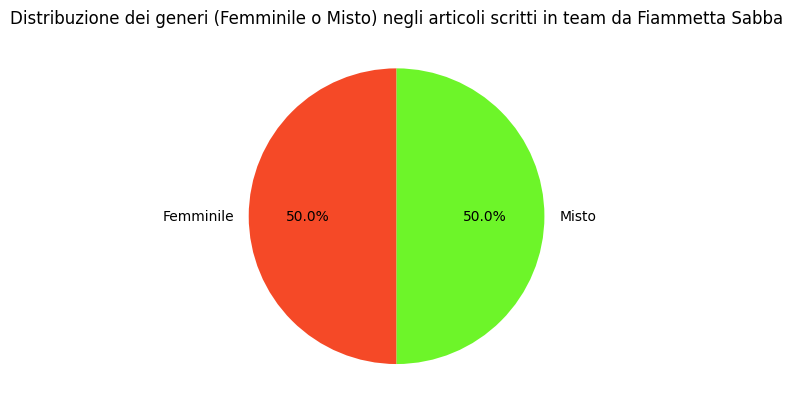

In [52]:
sabba_coautrice_conteggio_per_genere = fiammetta_sabba_coautrice[
    fiammetta_sabba_coautrice['genere_autori'].isin(['Femminile', 'Misto'])
    ]['genere_autori'].value_counts()

if sabba_coautrice_conteggio_per_genere.empty:                                                                          # si controlla che la serie non sia vuota
    print("Nessun articolo co-autore trovato per Fiammetta Sabba con genere 'Femminile' o 'Misto'.")
else:
    sabba_coautrice_conteggio_per_genere.plot.pie(autopct='%1.1f%%', startangle=90, title='Distribuzione dei generi (Femminile o Misto) negli articoli scritti in team da Fiammetta Sabba', colors=["#F54927", "#6DF529"], ylabel="")


Degli otto articoli scritti in team, si può notare come 4 siano composti da un team di genere misto e 4 da un team di genere femminile.

In [53]:
conteggio_pubblicazioni_team = fiammetta_sabba_coautrice['autori'].value_counts()

if not conteggio_pubblicazioni_team.empty:
                                                                                                # Verifichiamo se effettivamente ci sono pubblicazioni scritte in team
    print("Frequenza dei Team di Co-autori con Fiammetta Sabba:")
    for team, conto in conteggio_pubblicazioni_team.items():
        print(f"- {team}: {conto}")                                                             # Per ogni team singolo trovato e che non si ripete stampiamo il numero di quante volte lo troviamo
else:
    print("Nessun team di co-autori trovato per Fiammetta Sabba.")

Frequenza dei Team di Co-autori con Fiammetta Sabba:
- Fiammetta Sabba ; Giorgia Plachesi: 1
- Fiammetta Sabba ; Annantonia Martorano ; Elisabetta Angrisano ; Biancamaria Brumana ; Cinzia Cardinali ; Silvia Calamandrei ; Laura Giambastiani: 1
- Fiammetta Sabba ; Enrico Pio Ardolino: 1
- Fiammetta Sabba ; Giovanni Di Domenico: 1
- Fiammetta Sabba ; Lucia Sardo ; Carlo Bianchini: 1
- Fiammetta Sabba ; Giulia Crippa ; Andre Vieira de Freitas Araujo ; Gustavo Silva Saldanha: 1
- Fiammetta Sabba ; Roberta Cesana: 1
- Fiammetta Sabba ; Anna Giulia Cavagna: 1


Concludiamo che gli 8 articoli presentano 8 team distinti, l'unica autrice che si ripete in tutti è proprio Fiammetta Sabba.

####4.3.2.2 Anni in cui pubblica come unica autrice e in team
Sulla base degli articoli che hanno come autrice Fiammetta Sabba, si procede ad individuare gli anni pubblicazione e il loro andamento attraverso un grafico.

In [54]:
sabba_anni_pubblicazioni = df2[df2['autori'].str.contains('Fiammetta Sabba', na=False)]
print(sabba_anni_pubblicazioni['data_pubblicazione'].unique().dropna())

<IntegerArray>
[2020, 2018, 2016, 2021, 2014, 2024, 2023, 2013, 2019, 2017, 2015, 2025]
Length: 12, dtype: Int64


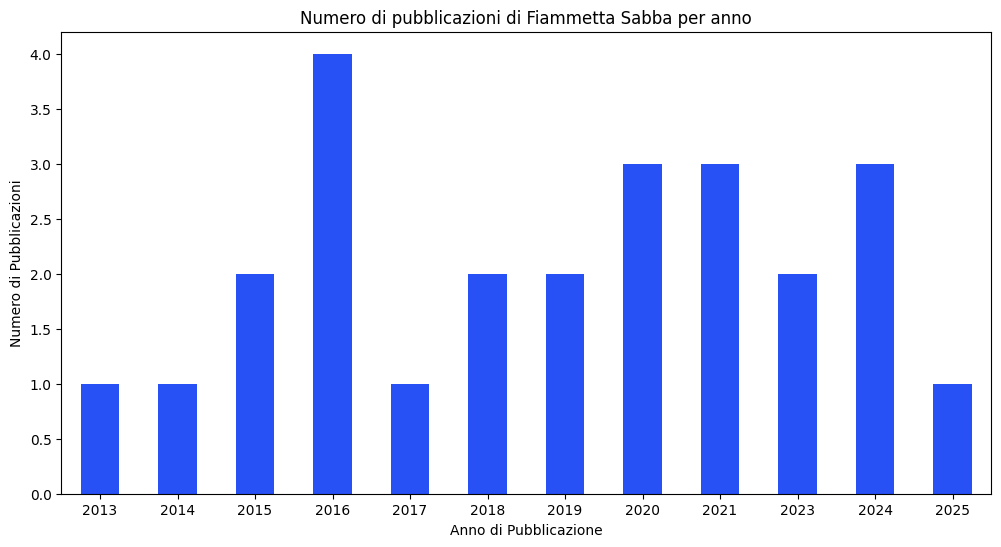

In [77]:
sabba_pubblicazioni = df2[df2['autori'].str.contains('Fiammetta Sabba', na=False)]
pubblicazioni_per_anno_sabba = sabba_pubblicazioni['data_pubblicazione'].value_counts().sort_index()

pubblicazioni_per_anno_sabba.plot.bar(
    title="Numero di pubblicazioni di Fiammetta Sabba per anno",
    figsize=(12, 6),
    ylabel='Numero di Pubblicazioni',
    xlabel='Anno di Pubblicazione',
    color='#2750F5',
    rot=360
);


Viene poi impiegato un altro grafico per individuare gli anni in cui pubblica di più in team, e se l'anno di punta del numero di articoli in team coincida con quello dei totali appena creato.

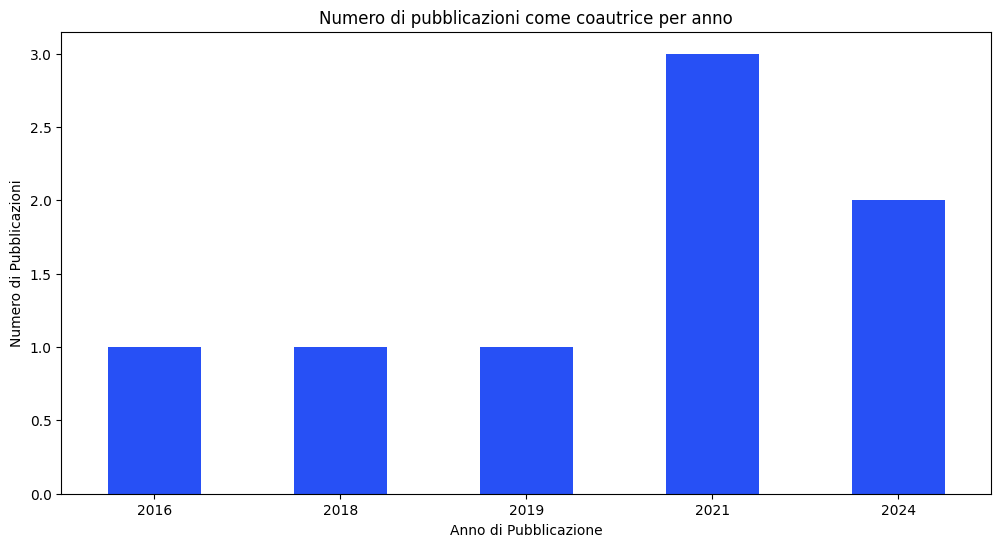

In [56]:
pubblicazioni_coautrice_per_anno = fiammetta_sabba_coautrice['data_pubblicazione'].value_counts().sort_index()

if not pubblicazioni_coautrice_per_anno.empty:
    pubblicazioni_coautrice_per_anno.plot.bar(
        title="Numero di pubblicazioni come coautrice per anno",
        figsize=(12, 6),
        ylabel='Numero di Pubblicazioni',
        xlabel='Anno di Pubblicazione',
        color='#2750F5',
        rot=360
    );
else:
  print("Nessun articolo co-autore trovato per Fiammetta Sabba.")

L'anno in cui Fiammetta ha pubblicato più articoli come coautrice non corrisponde all'anno in cui ha pubblicato di più come unica autrice nel nostro dataframe.

####4.3.2.3 Argomenti maggiormente trattati come unica autrice e in team
Sempre tenendo conto delle pubblicazioni attribuite a Fiammetta Sabba individuiamo ora i 5 argomenti che più si ripetono. Anche qui, come per Serrai, teniamo presente degli argomenti singoli e non associati.

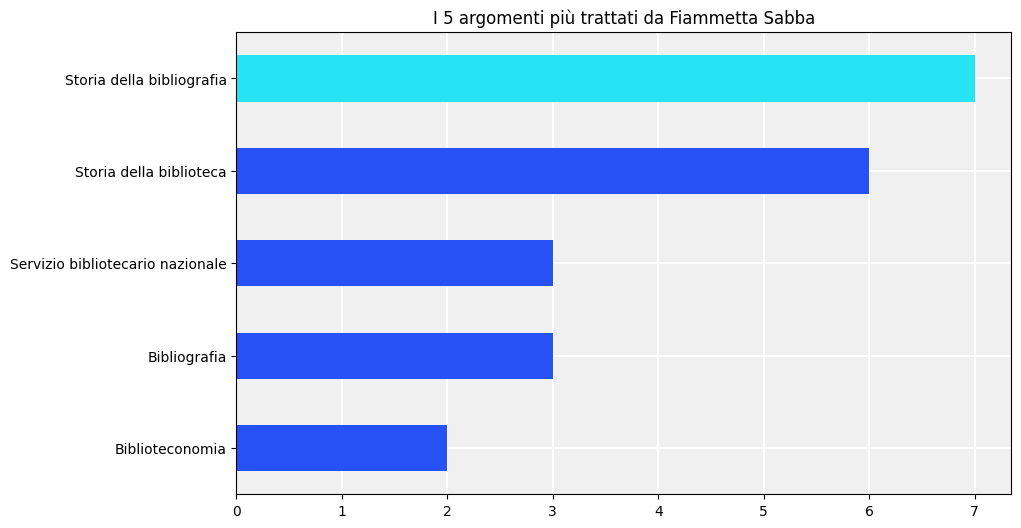

In [78]:
argomenti_sabba_separati = sabba_pubblicazioni['argomenti'].astype(str).str.split('; ').explode().dropna()
argomenti_sabba_separati = argomenti_sabba_separati[argomenti_sabba_separati.str.lower() != 'nan']

ax = argomenti_sabba_separati.value_counts().head(5).sort_values().plot.barh(
    title='I 5 argomenti più trattati da Fiammetta Sabba',
    color=['#2750F5','#2750F5','#2750F5','#2750F5','#27E4F5'],
    figsize=(10, 6),
    grid=True,
    ylabel="",
    width=0.5);
ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linewidth=1.5)
ax.set_axisbelow(True)

L'argomento maggiormente trattato dall'autrice risulta essere "Storia della bibliografia" seguito subito da "Storia della biblioteca" e dalle loro accezioni. A livello complessivo si attesta che negli argomenti trattati dall'autrice vi è una maggiore frequenza legata alla "Bibliografia" di conseguenza tende ad allontanarsi, seppur di poco, dalla tendenza del genere di appartenza.
Si ricercano anche gli argomenti trattati dalle sue pubblicazioni in team misto e femminile.

In [58]:
sabba_team_misti = df2[df2['autori'].astype(str).str.contains('Fiammetta Sabba', na=False) &
                          (df2['genere_autori'] == 'Misto')]

argomenti_sabba_misti_separati = sabba_team_misti['argomenti'].astype(str).str.split('; ').explode().dropna()
argomenti_sabba_misti_separati = argomenti_sabba_misti_separati[argomenti_sabba_misti_separati.str.lower() != 'nan']
conteggio_argomenti_sabba_misti = argomenti_sabba_misti_separati.value_counts()

print("Frequenza degli argomenti trattati negli articoli di Fiammetta Sabba con team misto:")
print(conteggio_argomenti_sabba_misti)

Frequenza degli argomenti trattati negli articoli di Fiammetta Sabba con team misto:
argomenti
Biblioteca                   1
Europa                       1
Lettura                      1
Biblioteca personale         1
Metadato                     1
Bibliografia                 1
Biblioteconomia              1
Storia della bibliografia    1
Name: count, dtype: int64


In [59]:
sabba_team_femminili = df2 [fiammetta_sabba_coautrice['autori'].astype(str).str.contains('Fiammetta Sabba', na=False) &
                          (df2['genere_autori'] == 'Femminile')]
argomenti_team_femminili = sabba_team_femminili['argomenti'].astype(str).str.split('; ').explode().dropna()
argomenti_team_femminili_sabba_separati = argomenti_team_femminili[argomenti_team_femminili.str.lower() != 'nan']
conteggio_argomenti_sabba_team_femminili = argomenti_team_femminili_sabba_separati.value_counts()

print("Frequenza degli argomenti trattati negli articoli di Fiammetta Sabba con team femminili:")
print(conteggio_argomenti_sabba_team_femminili)

Frequenza degli argomenti trattati negli articoli di Fiammetta Sabba con team femminili:
argomenti
Servizio bibliotecario nazionale    1
Grand tour                          1
Storia della bibliografia           1
Name: count, dtype: int64


Poiché tutti gli articoli scritti da Sabba in team si attestano alla frequenza di 1, non si possono tracciare delle tendenze. È comunque possibile individuare come, nei team misti, ritornino argomenti già conosciuti come "Biblioteca", "Bibliografia", "Biblioteconomia" e "Storia della bibliografia", che l'autrice scrive anche da sola e che si possono incontrare anche tra i 5 argomenti più studiati, a livello generale, dai team misti. Inoltre, "Storia della bibliografia" compare anche tra le pubblicazioni di team femminile andando a sostenere la leggera distanza dall'autrice dalla tendenza generale del genere di appartenenza.

#### 4.3.2.4 Editori con cui pubblica
Si indaga, infine, quali editori hanno pubblicato gli articoli di Fiammetta Sabba, prendendo come riferimenti i 5 più frequenti.

In [60]:
editori_sabba = sabba_pubblicazioni['editori'].astype(str).dropna()
top_5_editori_sabba = editori_sabba.value_counts().head(5)

print('Top 5 editori per Fiammetta Sabba')
display(top_5_editori_sabba)

Top 5 editori per Fiammetta Sabba


,count
editori,
Università di Bologna,22
Associazione Italiana Biblioteche,3


Come per Serrai, anche per Sabba gli editori presenti e maggiormente frequenti non sono 5, ma 2.
Scopriamo poi se vi è una propensione nelle pubblicazioni in team verso un determinato editore, tenendo presente come riferimento che si può raggiungere un massimo di 2 editori distinti e non più 5.

In [79]:
editori_sabba_team_misto = sabba_team_misti['editori'].astype(str).dropna()
top_2_editori_sabba_misto = editori_sabba_team_misto.value_counts().head(5)

print('Top 2 editori per Fiammetta Sabba con team misto')
display(top_2_editori_sabba_misto)

Top 2 editori per Fiammetta Sabba con team misto


,count
editori,
Università di Bologna,4


In [80]:
editori_sabba_coautrice_team_femminile = sabba_team_femminili['editori'].astype(str).dropna()
top_2_editori_sabba_coautrice_femminile = editori_sabba_coautrice_team_femminile.value_counts().head(5)

print('Top 2 editori per Fiammetta Sabba con team che sono donne')
display(top_2_editori_sabba_coautrice_femminile)

Top 2 editori per Fiammetta Sabba con team che sono donne


,count
editori,
Università di Bologna,3
Associazione Italiana Biblioteche,1


Concludiamo che per nessuno dei due autori più prolifici l'anno di maggior pubblicazione coincide con l'anno di pubblicazione più prolifico a livello assoluto.
Inoltre, entrambi come editore prevalente mostano l'Università di Bologna, che, come sopra, non coincide col trend generale dell'editore più rilevante per il database.

#5. Conclusioni

Le conclusioni sui risultati ottenuti, contenuti nel Jupyter Notebook, possono essere divise sulla base dell'analisi esplorativa e esplicativa.

Dall'analisi esplorativa le conclusioni evidenziano:
- Una copertura temporale ampia, dal 1816 al 2025, con un notevole aumento delle pubblicazioni negli ultimi 15 anni; il picco massimo è stato raggiunto nel 2020.
- L'editore più ricorrente è l'Associazione Italiana Biblioteche, che conta oltre 500 pubblicazioni.
- L'argomento maggiormente trattato è quello "Bibliotecario", ripetuto oltre 110 volte.
- Non notiamo una significativa distinzione di genere: gli uomini, da soli o in team dello stesso genere, sembrano pubblicare più delle donne per pochi punti percentuali. Inoltre, i team misti non sono popolari: compongono meno dell'8% dei casi totali.
- L'autore più prolifico è Alfredo Serrai, con 61 pubblicazioni, seguito da Fiammetta Sabba, con 25.

L'analisi esplicativa ha determinato che:
- La "Biblioteca" e le sue accezioni sono tra i temi maggiormente trattati, ricoprendo poco più del 22% del totale.
- Sembrano esserci argomenti più trattati da un genere rispetto all'altro, ma non in percentuali significative: gli stessi argomenti vengono analizzati tanto dagli uomini quanto dalle donne, ma i primi lavorano con maggior frequenza sul tema della bibliografia rispetto alle donne, mentre queste ruotano di più intorno alle biblioteche. Nei team misti si ripete quanto stabilito per uomini e donne, se non per un nuovo argomento "lavoro" che si distingue dal resto.
- Approfondendo i generi appuriamo che: gli uomini, come autori singoli, pubblicano più che le autrici donna, ma possiamo vedere che quest'ultime sono maggiormente propense a formare team dello stesso sesso. Inoltre, sommando le percentuali di Uomini e Donne, otteniamo come risultato 8%, che corrisponde alla portata degli articoli scritti da team misti: quindi, non si rileva più comune scrivere in team dello stesso genere rispetto a gruppi di lavoro misti, o viceversa. In totale, il 15.7% degli articoli è stato scritto da più mani.

Focalizzandoci sui due autori più prolifici per ciascun genere, si scopre che:
 - Alfredo Serrai
   - Non partecipa a team di lavoro, prediligendo la pubblicazione come unico autore e rispecchiando l'andamento del genere maschile;
   - L'anno in cui pubblica di più, il 2015, non corrisponde all'anno più prolifico a livello generale;
   - L'argomento di cui scrive maggiormente è la "Storia della bibliografia", in linea con il  dataset generale;
   - L'editore col quale egli pubblica più frequentemente è l'Università di Bologna, ben 60 scritti su 61; non si lega quindi all'editore più prolifico del database, l'Associazione Italiana Biblioteche, con cui egli pubblica un solo articolo.
 - Fiammetta Sabba
   - Partecipa a pubblicazioni realizzate in team, dimostrando l'andamento del genere femminile maggiormente portato alla scrittura a più mani, ma non ha una particolare propensione per team omogenei o eterogenei per sesso;
   - L'anno in cui pubblica di più è il 2016, dimostrandosi anch'essa non in linea con l'analisi generale; nemmeno l'anno in cui prende maggiormente parte a pubblicazioni in team, il 2021, corrisponde;
   - L'argomento di cui pubblica di più è la "Storia della bibliografia", allineandosi a Serrai ma non alla tendenza del suo genere di appartenenza. Per quanto riguarda le pubblicazioni in team misti, riprende gli argomenti comunemente trattati da questa categoria, ma non scrive dell'eccezione "lavoro" precedentemente individuata.
   - Anche per lei l'editore più ricorrende è l'UNIBO, non partecipando al trend generale dell'AIB, ma coincide con il comportamento di Serrai. Anche quando è in team l'editore più frequente non è l'AIB.

Le indagini, basate sulle scelte effettuata, hanno prodotto delle interessanti riflessioni sull'operato di alcuni autori e sugli argomenti maggiormente studiati; non hanno, però, evidenziato trend consistenti né anomalie consistenti all'interno del database.